# 08 - CS231 CNN Evaluation, Error Analysis & Grad-CAM

Notebook này dùng để **đánh giá chi tiết kết quả từ `06_cnn_train.ipynb`** và bổ sung **Grad-CAM** cho cả:

- `Simple CNN`
- `ResNet18 Fine-tuned`

Mục tiêu chính:

1. Kiểm tra các file output sau khi train.
2. Load `history`, `metrics`, `prediction`.
3. Đánh giá thêm `ResNet18 Feature Extraction` nếu thiếu prediction.
4. Vẽ training curves.
5. Vẽ confusion matrix.
6. Tạo top confused pairs.
7. Phân tích per-class metrics.
8. Hiển thị ảnh dự đoán sai.
9. Tạo Grad-CAM cho ảnh dự đoán đúng và sai của Simple CNN/ResNet18 Fine-tuned.
10. So sánh với CS114 nếu có file metrics.
11. Sinh nhận xét dùng trực tiếp cho báo cáo.

> Ghi chú: Grad-CAM giúp trực quan hóa vùng ảnh có ảnh hưởng lớn đến quyết định phân loại của model. Phần này rất phù hợp để tăng chiều sâu cho báo cáo CS231.


## 1. Import thư viện

Cell này import các thư viện cần dùng cho phân tích, biểu đồ, đọc file và inference tùy chọn.


In [ ]:
import os
import sys
import json
import random
import shutil
import subprocess
import warnings
from pathlib import Path
from typing import Dict, List, Optional, Tuple, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms, models

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")

try:
    from IPython.display import display, Markdown
except Exception:
    display = print
    Markdown = lambda x: x

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch: 2.10.0+cu128
Torchvision: 0.25.0+cu128
CUDA available: True
GPU: Tesla T4


## 2. Thiết lập `PROJECT_ROOT`

Notebook hỗ trợ 2 môi trường:

- **Google Colab**: ưu tiên dùng `/content/intel_image_project` nếu data đã được copy local từ file 06. Nếu chưa có, dùng trực tiếp thư mục project trên Google Drive.
- **Local**: nếu notebook nằm trong thư mục `notebooks/`, tự động lấy project root là thư mục cha.

Nếu đường dẫn Google Drive của bạn khác, chỉ cần sửa biến `DRIVE_ROOT` trong cell dưới.


In [ ]:
# =========================
# PROJECT ROOT CONFIG
# =========================

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

    # Đường dẫn project trên Google Drive của bạn.
    DRIVE_ROOT = Path("/content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project")

    # Nếu file 06 đã copy data/model/output về /content thì dùng local cho nhanh.
    LOCAL_ROOT = Path("/content/intel_image_project")

    if (LOCAL_ROOT / "data").exists():
        PROJECT_ROOT = LOCAL_ROOT
        print("Dùng PROJECT_ROOT local để chạy nhanh hơn.")
    elif DRIVE_ROOT.exists():
        PROJECT_ROOT = DRIVE_ROOT
        print("Không thấy data local. Dùng trực tiếp PROJECT_ROOT trên Google Drive.")
    else:
        raise FileNotFoundError(
            "Không tìm thấy project. Hãy kiểm tra lại DRIVE_ROOT hoặc copy project vào /content."
        )
else:
    CURRENT_DIR = Path.cwd()

    if CURRENT_DIR.name == "notebooks":
        PROJECT_ROOT = CURRENT_DIR.parent
    else:
        PROJECT_ROOT = CURRENT_DIR

    DRIVE_ROOT = None
    LOCAL_ROOT = PROJECT_ROOT

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
SPLIT_DIR = DATA_DIR / "splits"
METADATA_DIR = DATA_DIR / "metadata"

MODEL_DIR = PROJECT_ROOT / "models" / "cs231"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
METRIC_DIR = OUTPUT_DIR / "metrics"
PRED_DIR = OUTPUT_DIR / "predictions"
FIGURE_DIR = OUTPUT_DIR / "figures" / "cs231"
FINAL_FIGURE_DIR = OUTPUT_DIR / "figures" / "final"
ERROR_FIGURE_DIR = FIGURE_DIR / "misclassified_examples"

for directory in [MODEL_DIR, METRIC_DIR, PRED_DIR, FIGURE_DIR, FINAL_FIGURE_DIR, ERROR_FIGURE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("IN_COLAB:", IN_COLAB)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("MODEL_DIR:", MODEL_DIR)
print("METRIC_DIR:", METRIC_DIR)
print("PRED_DIR:", PRED_DIR)
print("FIGURE_DIR:", FIGURE_DIR)


Mounted at /content/drive
Không thấy data local. Dùng trực tiếp PROJECT_ROOT trên Google Drive.
IN_COLAB: True
PROJECT_ROOT: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project
DATA_DIR: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/data
MODEL_DIR: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/models/cs231
METRIC_DIR: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/metrics
PRED_DIR: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/predictions
FIGURE_DIR: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/figures/cs231


## 3. Cấu hình chung

Giữ cấu hình ảnh đúng với file 06:

- Simple CNN: ảnh `128x128`, normalize theo mean/std của dataset.
- ResNet18: ảnh `224x224`, normalize theo ImageNet.


In [ ]:
# =========================
# GLOBAL CONFIG
# =========================

SEED = 42
NUM_CLASSES = 6
NUM_WORKERS = 2 if IN_COLAB else 0

IMAGE_SIZE_SIMPLE = 128
IMAGE_SIZE_TRANSFER = 224

BATCH_SIZE_SIMPLE = 64
BATCH_SIZE_TRANSFER = 32

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATASET_MEAN = [0.43018116, 0.45747542, 0.45382798]
DATASET_STD = [0.26941103, 0.26793626, 0.29834034]

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Nếu prediction của ResNet18 Feature Extraction chưa tồn tại,
# notebook sẽ cố gắng load checkpoint và chạy inference trên test set.
RUN_FEATURE_EXTRACTOR_TEST_IF_MISSING = True

# Số ảnh sai hiển thị trong grid.
NUM_MISCLASSIFIED_IMAGES = 18


def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)
print("DEVICE:", DEVICE)


DEVICE: cuda


## 4. Đọc split và mapping nhãn

Cell này đọc lại các file split đã dùng ở CS114/CS231 để bảo đảm phân tích dựa trên cùng test set.


In [ ]:
TRAIN_CSV = SPLIT_DIR / "train.csv"
VAL_CSV = SPLIT_DIR / "val.csv"
TEST_CSV = SPLIT_DIR / "test.csv"
CLASS_TO_IDX_JSON = METADATA_DIR / "class_to_idx.json"

required_base_files = [TRAIN_CSV, VAL_CSV, TEST_CSV, CLASS_TO_IDX_JSON]

for file_path in required_base_files:
    if not file_path.exists():
        raise FileNotFoundError(f"Không tìm thấy file bắt buộc: {file_path}")

train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

with open(CLASS_TO_IDX_JSON, "r", encoding="utf-8") as f:
    class_to_idx = json.load(f)

class_to_idx = {str(k): int(v) for k, v in class_to_idx.items()}
idx_to_class = {v: k for k, v in class_to_idx.items()}
class_names = [idx_to_class[i] for i in range(len(idx_to_class))]

print("Train shape:", train_df.shape)
print("Val shape  :", val_df.shape)
print("Test shape :", test_df.shape)
print("Class names:", class_names)

display(test_df.head())


Train shape: (11212, 11)
Val shape  : (2804, 11)
Test shape : (3000, 10)
Class names: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


,split,label,file_name,relative_path,width,height,mode,error,file_hash,label_idx
0,test,buildings,20057.jpg,seg_test/buildings/20057.jpg,150,150,RGB,NaN,c05af5c7bcce817b4e03c89cf99523b3,0
1,test,buildings,20060.jpg,seg_test/buildings/20060.jpg,150,150,RGB,NaN,294b7b292e7ba7d938b7819cde55125c,0
2,test,buildings,20061.jpg,seg_test/buildings/20061.jpg,150,150,RGB,NaN,1dc62bcc7c181f63d546cef3a108ac0e,0
3,test,buildings,20064.jpg,seg_test/buildings/20064.jpg,150,150,RGB,NaN,b1369f91a642bda82a51b041f97870a9,0
4,test,buildings,20073.jpg,seg_test/buildings/20073.jpg,150,150,RGB,NaN,3c520c75fde0970f78531d6fbaa334bb,0


In [ ]:
def find_column(df: pd.DataFrame, candidates: List[str]) -> Optional[str]:
    for col in candidates:
        if col in df.columns:
            return col
    return None


PATH_COL = find_column(
    train_df,
    ["relative_path", "path", "filepath", "file_path", "image_path", "full_path"]
)

LABEL_COL = find_column(
    train_df,
    ["label", "class_name", "class", "true_label"]
)

LABEL_IDX_COL = find_column(
    train_df,
    ["label_idx", "class_idx", "target", "true_label_idx"]
)

if PATH_COL is None:
    raise ValueError("Không tìm thấy cột đường dẫn ảnh.")

if LABEL_COL is None and LABEL_IDX_COL is None:
    raise ValueError("Không tìm thấy cột nhãn.")


def normalize_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["relative_path"] = df[PATH_COL].astype(str)

    if LABEL_IDX_COL is not None:
        df["label_idx"] = df[LABEL_IDX_COL].astype(int)

        if LABEL_COL is not None:
            df["label"] = df[LABEL_COL].astype(str)
        else:
            df["label"] = df["label_idx"].map(idx_to_class)
    else:
        df["label"] = df[LABEL_COL].astype(str)
        df["label_idx"] = df["label"].map(class_to_idx).astype(int)

    return df


train_df = normalize_dataframe(train_df)
val_df = normalize_dataframe(val_df)
test_df = normalize_dataframe(test_df)

split_summary = pd.DataFrame({
    "train": train_df["label"].value_counts().sort_index(),
    "val": val_df["label"].value_counts().sort_index(),
    "test": test_df["label"].value_counts().sort_index(),
}).fillna(0).astype(int)

print("PATH_COL:", PATH_COL)
print("LABEL_COL:", LABEL_COL)
print("LABEL_IDX_COL:", LABEL_IDX_COL)

display(split_summary)


PATH_COL: relative_path
LABEL_COL: label
LABEL_IDX_COL: label_idx


,train,val,test
label,,,
buildings,1752,438,437
forest,1815,454,474
glacier,1923,481,553
mountain,2004,501,525
sea,1817,455,510
street,1901,475,501


## 5. Kiểm tra output từ file 06

Cell này giúp phát hiện nhanh file nào đã có, file nào còn thiếu.


In [ ]:
expected_outputs = {
    "Simple CNN checkpoint": MODEL_DIR / "simple_cnn_best.pth",
    "ResNet18 Feature Extractor checkpoint": MODEL_DIR / "resnet18_feature_extractor_best.pth",
    "ResNet18 Fine-tuned checkpoint": MODEL_DIR / "resnet18_finetuned_best.pth",

    "Simple CNN history": METRIC_DIR / "cs231_simple_cnn_history.csv",
    "ResNet18 Feature Extractor history": METRIC_DIR / "cs231_resnet18_feature_extractor_history.csv",
    "ResNet18 Fine-tuned history": METRIC_DIR / "cs231_resnet18_finetuned_history.csv",

    "Simple CNN metrics": METRIC_DIR / "cs231_simple_cnn_test_metrics.json",
    "ResNet18 Feature Extractor metrics": METRIC_DIR / "cs231_resnet18_feature_extractor_test_metrics.json",
    "ResNet18 Fine-tuned metrics": METRIC_DIR / "cs231_resnet18_finetuned_test_metrics.json",

    "Simple CNN predictions": PRED_DIR / "cs231_simple_cnn_test_predictions.csv",
    "ResNet18 Feature Extractor predictions": PRED_DIR / "cs231_resnet18_feature_extractor_test_predictions.csv",
    "ResNet18 Fine-tuned predictions": PRED_DIR / "cs231_resnet18_finetuned_test_predictions.csv",
}

output_check_rows = []

for name, path in expected_outputs.items():
    output_check_rows.append({
        "item": name,
        "path": str(path),
        "exists": path.exists(),
        "size_mb": round(path.stat().st_size / (1024 * 1024), 3) if path.exists() else None,
    })

output_check_df = pd.DataFrame(output_check_rows)
display(output_check_df)

missing_items = output_check_df[~output_check_df["exists"]]

if len(missing_items) == 0:
    print("Tất cả output mong đợi đều đã tồn tại.")
else:
    print("Một số output đang thiếu. Nếu thiếu Feature Extractor test metrics/predictions thì notebook có thể tự bổ sung ở phần sau.")
    display(missing_items[["item", "path"]])


,item,path,exists,size_mb
0,Simple CNN checkpoint,/content/drive/MyDrive/hk2 2025 - 2026/ CS231....,True,4.864
1,ResNet18 Feature Extractor checkpoint,/content/drive/MyDrive/hk2 2025 - 2026/ CS231....,True,42.752
2,ResNet18 Fine-tuned checkpoint,/content/drive/MyDrive/hk2 2025 - 2026/ CS231....,True,106.803
3,Simple CNN history,/content/drive/MyDrive/hk2 2025 - 2026/ CS231....,True,0.010
4,ResNet18 Feature Extractor history,/content/drive/MyDrive/hk2 2025 - 2026/ CS231....,True,0.003
5,ResNet18 Fine-tuned history,/content/drive/MyDrive/hk2 2025 - 2026/ CS231....,True,0.003
6,Simple CNN metrics,/content/drive/MyDrive/hk2 2025 - 2026/ CS231....,True,0.001
7,ResNet18 Feature Extractor metrics,/content/drive/MyDrive/hk2 2025 - 2026/ CS231....,False,NaN
8,ResNet18 Fine-tuned metrics,/content/drive/MyDrive/hk2 2025 - 2026/ CS231....,True,0.001
9,Simple CNN predictions,/content/drive/MyDrive/hk2 2025 - 2026/ CS231....,True,0.564


Một số output đang thiếu. Nếu thiếu Feature Extractor test metrics/predictions thì notebook có thể tự bổ sung ở phần sau.


,item,path
7,ResNet18 Feature Extractor metrics,/content/drive/MyDrive/hk2 2025 - 2026/ CS231....
10,ResNet18 Feature Extractor predictions,/content/drive/MyDrive/hk2 2025 - 2026/ CS231....


## 6. Helper functions

Các hàm hỗ trợ đọc/ghi JSON, load prediction, tính metric, lưu hình và resolve đường dẫn ảnh.


In [ ]:
def read_json(path: Path) -> Dict[str, Any]:
    if not path.exists():
        return {}

    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def save_json(data: Dict[str, Any], path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)

    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=4, ensure_ascii=False)


def save_dataframe(df: pd.DataFrame, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)
    print("Saved:", path)


def save_current_figure(path: Path, dpi: int = 160) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print("Saved figure:", path)


def compute_metrics_from_predictions(pred_df: pd.DataFrame) -> Dict[str, float]:
    y_true = pred_df["true_label_idx"].astype(int).values
    y_pred = pred_df["pred_label_idx"].astype(int).values

    accuracy = accuracy_score(y_true, y_pred)

    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    return {
        "accuracy": float(accuracy),
        "macro_precision": float(macro_precision),
        "macro_recall": float(macro_recall),
        "macro_f1": float(macro_f1),
        "weighted_precision": float(weighted_precision),
        "weighted_recall": float(weighted_recall),
        "weighted_f1": float(weighted_f1),
        "num_test_samples": int(len(pred_df)),
        "num_correct": int(pred_df["is_correct"].astype(bool).sum()),
        "num_wrong": int((~pred_df["is_correct"].astype(bool)).sum()),
    }


def normalize_prediction_df(pred_df: pd.DataFrame) -> pd.DataFrame:
    pred_df = pred_df.copy()

    required_cols = ["relative_path", "true_label_idx", "pred_label_idx"]
    for col in required_cols:
        if col not in pred_df.columns:
            raise ValueError(f"Prediction file thiếu cột bắt buộc: {col}")

    pred_df["true_label_idx"] = pred_df["true_label_idx"].astype(int)
    pred_df["pred_label_idx"] = pred_df["pred_label_idx"].astype(int)

    if "true_label" not in pred_df.columns:
        pred_df["true_label"] = pred_df["true_label_idx"].map(idx_to_class)

    if "pred_label" not in pred_df.columns:
        pred_df["pred_label"] = pred_df["pred_label_idx"].map(idx_to_class)

    if "is_correct" not in pred_df.columns:
        pred_df["is_correct"] = pred_df["true_label_idx"] == pred_df["pred_label_idx"]
    else:
        # Nếu đọc từ CSV, bool có thể bị parse thành string.
        if pred_df["is_correct"].dtype == object:
            pred_df["is_correct"] = pred_df["is_correct"].astype(str).str.lower().isin(["true", "1", "yes"])
        else:
            pred_df["is_correct"] = pred_df["is_correct"].astype(bool)

    if "confidence" not in pred_df.columns:
        prob_cols = [col for col in pred_df.columns if col.startswith("prob_")]
        if prob_cols:
            pred_df["confidence"] = pred_df[prob_cols].max(axis=1)
        else:
            pred_df["confidence"] = np.nan

    return pred_df


def resolve_image_path(relative_path: str) -> Path:
    rel = str(relative_path).replace("\\", "/")
    path_obj = Path(rel)

    candidates = []

    if path_obj.is_absolute():
        candidates.append(path_obj)

    candidates.extend([
        PROJECT_ROOT / rel,
        RAW_DIR / rel,
        DATA_DIR / rel,
    ])

    # Nếu đang chạy local /content nhưng ảnh không có, thử Google Drive.
    if IN_COLAB and DRIVE_ROOT is not None:
        candidates.extend([
            DRIVE_ROOT / rel,
            DRIVE_ROOT / "data" / "raw" / rel,
            DRIVE_ROOT / "data" / rel,
        ])

    for candidate in candidates:
        if candidate.exists():
            return candidate

    raise FileNotFoundError(f"Không tìm thấy ảnh: {relative_path}")


## 7. Định nghĩa Dataset và model để inference tùy chọn

Phần này cần cho trường hợp bạn chưa có prediction của `ResNet18 Feature Extraction` và muốn notebook tự tạo.


In [ ]:
class IntelSceneDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, transform: Optional[Any] = None, return_path: bool = True):
        self.df = dataframe.reset_index(drop=True).copy()
        self.transform = transform
        self.return_path = return_path

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, index: int):
        row = self.df.iloc[index]
        relative_path = row["relative_path"]
        label_idx = int(row["label_idx"])

        image_path = resolve_image_path(relative_path)
        image = Image.open(image_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        if self.return_path:
            return image, label_idx, relative_path

        return image, label_idx


class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int = 6, dropout: float = 0.4):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.classifier(x)
        return x


def create_resnet18(num_classes: int = 6, pretrained: bool = False) -> nn.Module:
    if pretrained:
        try:
            weights = models.ResNet18_Weights.DEFAULT
            model = models.resnet18(weights=weights)
        except Exception:
            model = models.resnet18(pretrained=True)
    else:
        try:
            model = models.resnet18(weights=None)
        except Exception:
            model = models.resnet18(pretrained=False)

    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model


def load_model_state(model: nn.Module, checkpoint_path: Path, device: torch.device) -> Dict[str, Any]:
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    return checkpoint


@torch.no_grad()
def predict_loader(model: nn.Module, loader: DataLoader, device: torch.device) -> pd.DataFrame:
    model.eval()
    model = model.to(device)

    rows = []

    for images, labels, paths in tqdm(loader, desc="Predict", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)
        confidences = torch.max(probs, dim=1).values

        labels_np = labels.detach().cpu().numpy()
        preds_np = preds.detach().cpu().numpy()
        confidences_np = confidences.detach().cpu().numpy()
        probs_np = probs.detach().cpu().numpy()

        for i in range(len(paths)):
            true_idx = int(labels_np[i])
            pred_idx = int(preds_np[i])

            row = {
                "relative_path": paths[i],
                "true_label_idx": true_idx,
                "pred_label_idx": pred_idx,
                "true_label": idx_to_class[true_idx],
                "pred_label": idx_to_class[pred_idx],
                "is_correct": bool(true_idx == pred_idx),
                "confidence": float(confidences_np[i]),
            }

            for class_idx, class_name in idx_to_class.items():
                row[f"prob_{class_name}"] = float(probs_np[i, class_idx])

            rows.append(row)

    return pd.DataFrame(rows)


## 8. Tạo DataLoader test cho inference tùy chọn

Chỉ dùng khi cần tạo thêm prediction cho Feature Extraction. Nếu prediction đã có sẵn, cell này vẫn chạy rất nhẹ.


In [ ]:
transfer_eval_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(IMAGE_SIZE_TRANSFER),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

simple_eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE_SIMPLE, IMAGE_SIZE_SIMPLE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=DATASET_MEAN, std=DATASET_STD)
])

transfer_test_dataset = IntelSceneDataset(test_df, transform=transfer_eval_transform)

transfer_test_loader = DataLoader(
    transfer_test_dataset,
    batch_size=BATCH_SIZE_TRANSFER,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("Transfer test batches:", len(transfer_test_loader))


Transfer test batches: 94


## 9. Đánh giá thêm ResNet18 Feature Extraction nếu thiếu prediction

File 06 của bạn đã train `resnet18_feature_extractor_best.pth`, nhưng thường chưa test riêng model này. Cell dưới sẽ tự kiểm tra:

- Nếu đã có `cs231_resnet18_feature_extractor_test_predictions.csv`: bỏ qua.
- Nếu chưa có nhưng có checkpoint: load checkpoint và chạy inference test.
- Nếu thiếu checkpoint hoặc thiếu ảnh: bỏ qua và báo lỗi rõ ràng.


In [ ]:
feature_pred_path = PRED_DIR / "cs231_resnet18_feature_extractor_test_predictions.csv"
feature_metric_path = METRIC_DIR / "cs231_resnet18_feature_extractor_test_metrics.json"
feature_per_class_path = METRIC_DIR / "cs231_resnet18_feature_extractor_per_class_metrics.csv"
feature_checkpoint_path = MODEL_DIR / "resnet18_feature_extractor_best.pth"

if feature_pred_path.exists():
    print("Prediction của ResNet18 Feature Extraction đã tồn tại, bỏ qua inference.")
elif RUN_FEATURE_EXTRACTOR_TEST_IF_MISSING and feature_checkpoint_path.exists():
    print("Đang chạy inference cho ResNet18 Feature Extraction...")

    try:
        model = create_resnet18(num_classes=NUM_CLASSES, pretrained=False).to(DEVICE)
        checkpoint = load_model_state(model, feature_checkpoint_path, DEVICE)
        print(
            "Loaded checkpoint:",
            "epoch=", checkpoint.get("epoch"),
            "best_metric=", checkpoint.get("best_metric")
        )

        feature_pred_df = predict_loader(model, transfer_test_loader, DEVICE)
        feature_pred_df = normalize_prediction_df(feature_pred_df)
        save_dataframe(feature_pred_df, feature_pred_path)

        feature_metrics = compute_metrics_from_predictions(feature_pred_df)
        feature_metrics["model_name"] = "resnet18_feature_extractor"
        feature_metrics["checkpoint_path"] = str(feature_checkpoint_path)
        feature_metrics["prediction_path"] = str(feature_pred_path)
        save_json(feature_metrics, feature_metric_path)

        report_dict = classification_report(
            feature_pred_df["true_label_idx"],
            feature_pred_df["pred_label_idx"],
            target_names=class_names,
            output_dict=True,
            zero_division=0
        )
        feature_per_class_df = pd.DataFrame(report_dict).transpose()
        feature_per_class_df.to_csv(feature_per_class_path)
        print("Saved:", feature_metric_path)
        print("Saved:", feature_per_class_path)

        display(feature_metrics)
        display(feature_per_class_df)
    except Exception as e:
        print("Không thể chạy inference cho Feature Extraction.")
        print("Lý do:", repr(e))
else:
    print("Thiếu prediction và/hoặc checkpoint Feature Extraction. Bỏ qua phần inference này.")


Đang chạy inference cho ResNet18 Feature Extraction...
Loaded checkpoint: epoch= 5 best_metric= 0.9054971860861616


Predict:   0%|          | 0/94 [00:00<?, ?it/s]

Saved: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/predictions/cs231_resnet18_feature_extractor_test_predictions.csv
Saved: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/metrics/cs231_resnet18_feature_extractor_test_metrics.json
Saved: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/metrics/cs231_resnet18_feature_extractor_per_class_metrics.csv


{'accuracy': 0.9033333333333333,
 'macro_precision': 0.9062377271211971,
 'macro_recall': 0.9063374082143215,
 'macro_f1': 0.9045238698804927,
 'weighted_precision': 0.9045428483302344,
 'weighted_recall': 0.9033333333333333,
 'weighted_f1': 0.9021016598038978,
 'num_test_samples': 3000,
 'num_correct': 2710,
 'num_wrong': 290,
 'model_name': 'resnet18_feature_extractor',
 'checkpoint_path': '/content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/models/cs231/resnet18_feature_extractor_best.pth',
 'prediction_path': '/content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/predictions/cs231_resnet18_feature_extractor_test_predictions.csv'}

,precision,recall,f1-score,support
buildings,0.887446,0.938215,0.912125,437.000000
forest,0.967280,0.997890,0.982347,474.000000
glacier,0.815000,0.884268,0.848222,553.000000
mountain,0.903002,0.744762,0.816284,525.000000
sea,0.926554,0.964706,0.945245,510.000000
street,0.938144,0.908184,0.922921,501.000000
accuracy,0.903333,0.903333,0.903333,0.903333
macro avg,0.906238,0.906337,0.904524,3000.000000
weighted avg,0.904543,0.903333,0.902102,3000.000000


## 10. Load metrics, prediction và history

Từ đây trở đi, notebook phân tích các file đã có trong `outputs/metrics` và `outputs/predictions`.


In [ ]:
MODEL_SPECS = {
    "simple_cnn": {
        "display_name": "Simple CNN",
        "family": "CNN from scratch",
        "prediction_path": PRED_DIR / "cs231_simple_cnn_test_predictions.csv",
        "metrics_path": METRIC_DIR / "cs231_simple_cnn_test_metrics.json",
        "per_class_path": METRIC_DIR / "cs231_simple_cnn_per_class_metrics.csv",
        "history_path": METRIC_DIR / "cs231_simple_cnn_history.csv",
    },
    "resnet18_feature_extractor": {
        "display_name": "ResNet18 Feature Extraction",
        "family": "Transfer Learning",
        "prediction_path": PRED_DIR / "cs231_resnet18_feature_extractor_test_predictions.csv",
        "metrics_path": METRIC_DIR / "cs231_resnet18_feature_extractor_test_metrics.json",
        "per_class_path": METRIC_DIR / "cs231_resnet18_feature_extractor_per_class_metrics.csv",
        "history_path": METRIC_DIR / "cs231_resnet18_feature_extractor_history.csv",
    },
    "resnet18_finetuned": {
        "display_name": "ResNet18 Fine-tuned",
        "family": "Transfer Learning",
        "prediction_path": PRED_DIR / "cs231_resnet18_finetuned_test_predictions.csv",
        "metrics_path": METRIC_DIR / "cs231_resnet18_finetuned_test_metrics.json",
        "per_class_path": METRIC_DIR / "cs231_resnet18_finetuned_per_class_metrics.csv",
        "history_path": METRIC_DIR / "cs231_resnet18_finetuned_history.csv",
    },
}

predictions: Dict[str, pd.DataFrame] = {}
metrics: Dict[str, Dict[str, Any]] = {}
histories: Dict[str, pd.DataFrame] = {}
per_class_reports: Dict[str, pd.DataFrame] = {}

for model_key, spec in MODEL_SPECS.items():
    pred_path = spec["prediction_path"]
    metric_path = spec["metrics_path"]
    history_path = spec["history_path"]
    per_class_path = spec["per_class_path"]

    if pred_path.exists():
        pred_df = pd.read_csv(pred_path)
        pred_df = normalize_prediction_df(pred_df)
        predictions[model_key] = pred_df

        # Luôn recompute metrics từ prediction để đồng bộ.
        recomputed_metrics = compute_metrics_from_predictions(pred_df)
        file_metrics = read_json(metric_path)
        merged_metrics = {**file_metrics, **recomputed_metrics}
        merged_metrics["model_name"] = model_key
        metrics[model_key] = merged_metrics
    else:
        print(f"Missing prediction: {model_key} -> {pred_path}")

    if history_path.exists():
        histories[model_key] = pd.read_csv(history_path)
    else:
        print(f"Missing history: {model_key} -> {history_path}")

    if per_class_path.exists():
        per_class_df = pd.read_csv(per_class_path, index_col=0)
        per_class_reports[model_key] = per_class_df

print("Loaded predictions:", list(predictions.keys()))
print("Loaded histories:", list(histories.keys()))
print("Loaded metrics:", list(metrics.keys()))


Loaded predictions: ['simple_cnn', 'resnet18_feature_extractor', 'resnet18_finetuned']
Loaded histories: ['simple_cnn', 'resnet18_feature_extractor', 'resnet18_finetuned']
Loaded metrics: ['simple_cnn', 'resnet18_feature_extractor', 'resnet18_finetuned']


## 11. Kiểm tra integrity của prediction

Mục tiêu: xác nhận mỗi prediction file có đúng `3000` dòng test và nhãn hợp lệ.


In [ ]:
integrity_rows = []

for model_key, pred_df in predictions.items():
    spec = MODEL_SPECS[model_key]
    invalid_true = sorted(set(pred_df["true_label_idx"]) - set(range(NUM_CLASSES)))
    invalid_pred = sorted(set(pred_df["pred_label_idx"]) - set(range(NUM_CLASSES)))

    integrity_rows.append({
        "model": spec["display_name"],
        "num_rows": len(pred_df),
        "expected_test_rows": len(test_df),
        "row_count_ok": len(pred_df) == len(test_df),
        "num_correct": int(pred_df["is_correct"].sum()),
        "num_wrong": int((~pred_df["is_correct"]).sum()),
        "invalid_true_label_idx": invalid_true,
        "invalid_pred_label_idx": invalid_pred,
        "has_confidence": "confidence" in pred_df.columns,
    })

integrity_df = pd.DataFrame(integrity_rows)
display(integrity_df)

save_dataframe(integrity_df, METRIC_DIR / "cs231_prediction_integrity_check.csv")


,model,num_rows,expected_test_rows,row_count_ok,num_correct,num_wrong,invalid_true_label_idx,invalid_pred_label_idx,has_confidence
0,Simple CNN,3000,3000,True,2654,346,[],[],True
1,ResNet18 Feature Extraction,3000,3000,True,2710,290,[],[],True
2,ResNet18 Fine-tuned,3000,3000,True,2800,200,[],[],True


Saved: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/metrics/cs231_prediction_integrity_check.csv


## 12. Bảng tổng hợp test metrics CS231

Đây là bảng chính nên đưa vào báo cáo.


In [ ]:
summary_rows = []

for model_key, metric in metrics.items():
    spec = MODEL_SPECS[model_key]
    summary_rows.append({
        "model_key": model_key,
        "model": spec["display_name"],
        "family": spec["family"],
        "test_accuracy": metric.get("accuracy"),
        "test_macro_precision": metric.get("macro_precision"),
        "test_macro_recall": metric.get("macro_recall"),
        "test_macro_f1": metric.get("macro_f1"),
        "test_weighted_f1": metric.get("weighted_f1"),
        "num_test_samples": metric.get("num_test_samples"),
        "num_correct": metric.get("num_correct"),
        "num_wrong": metric.get("num_wrong"),
    })

cs231_summary_df = pd.DataFrame(summary_rows)
cs231_summary_df = cs231_summary_df.sort_values("test_macro_f1", ascending=False).reset_index(drop=True)

display(cs231_summary_df)
save_dataframe(cs231_summary_df, METRIC_DIR / "cs231_cnn_model_comparison.csv")

best_row = cs231_summary_df.iloc[0]
print(f"Best CS231 model: {best_row['model']} | Accuracy={best_row['test_accuracy']:.4f} | Macro F1={best_row['test_macro_f1']:.4f}")


,model_key,model,family,test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1,test_weighted_f1,num_test_samples,num_correct,num_wrong
0,resnet18_finetuned,ResNet18 Fine-tuned,Transfer Learning,0.933333,0.934233,0.935365,0.934397,0.933095,3000,2800,200
1,resnet18_feature_extractor,ResNet18 Feature Extraction,Transfer Learning,0.903333,0.906238,0.906337,0.904524,0.902102,3000,2710,290
2,simple_cnn,Simple CNN,CNN from scratch,0.884667,0.888781,0.884124,0.885000,0.884297,3000,2654,346


Saved: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/metrics/cs231_cnn_model_comparison.csv
Best CS231 model: ResNet18 Fine-tuned | Accuracy=0.9333 | Macro F1=0.9344


## 13. Vẽ biểu đồ so sánh model CS231

Biểu đồ này dùng để đưa vào báo cáo/slide phần tổng kết kết quả.


Saved figure: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/figures/cs231/cs231_model_comparison_accuracy_macro_f1.png


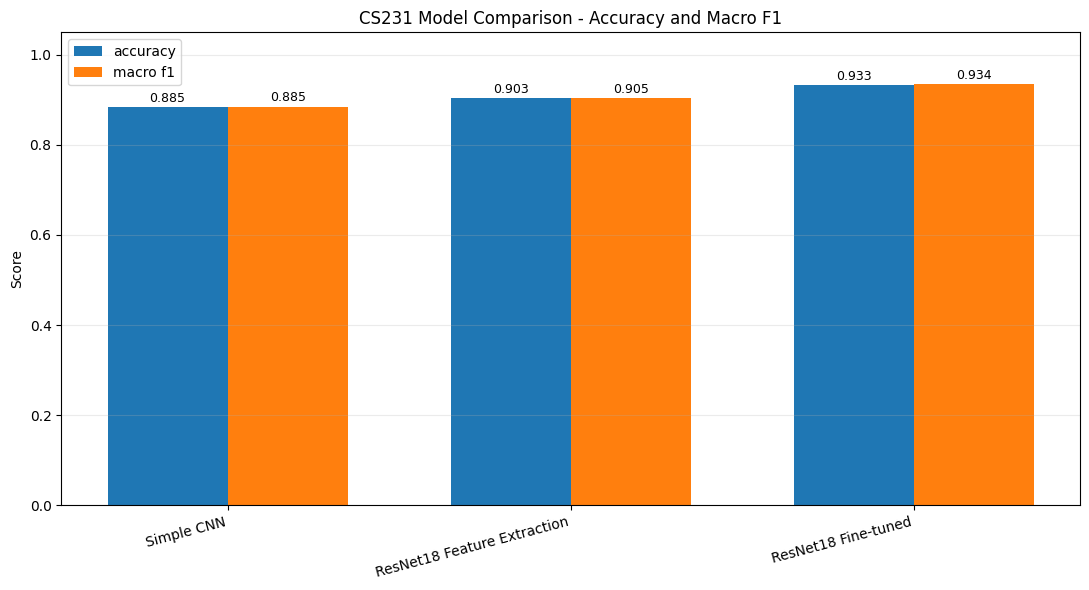

In [ ]:
def plot_metric_bar(df: pd.DataFrame, metric_cols: List[str], title: str, save_path: Path) -> None:
    plot_df = df.copy().sort_values("test_macro_f1", ascending=True)
    x = np.arange(len(plot_df))
    width = 0.35 if len(metric_cols) == 2 else 0.25

    plt.figure(figsize=(11, 6))

    for i, col in enumerate(metric_cols):
        offset = (i - (len(metric_cols) - 1) / 2) * width
        values = plot_df[col].astype(float).values
        plt.bar(x + offset, values, width, label=col.replace("test_", "").replace("_", " "))

        for xi, yi in zip(x + offset, values):
            plt.text(xi, yi + 0.005, f"{yi:.3f}", ha="center", va="bottom", fontsize=9)

    plt.xticks(x, plot_df["model"], rotation=15, ha="right")
    plt.ylim(0, 1.05)
    plt.ylabel("Score")
    plt.title(title)
    plt.legend()
    plt.grid(axis="y", alpha=0.25)
    save_current_figure(save_path)
    plt.show()


if len(cs231_summary_df) > 0:
    plot_metric_bar(
        cs231_summary_df,
        ["test_accuracy", "test_macro_f1"],
        "CS231 Model Comparison - Accuracy and Macro F1",
        FIGURE_DIR / "cs231_model_comparison_accuracy_macro_f1.png"
    )


## 14. Training curves

Mục tiêu:

- Kiểm tra model có học ổn không.
- Phát hiện overfitting: train tăng nhưng validation không tăng hoặc giảm.
- Xác định epoch tốt nhất theo validation Macro F1.


Plotting: Simple CNN
Saved figure: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/figures/cs231/training_curves_simple_cnn.png


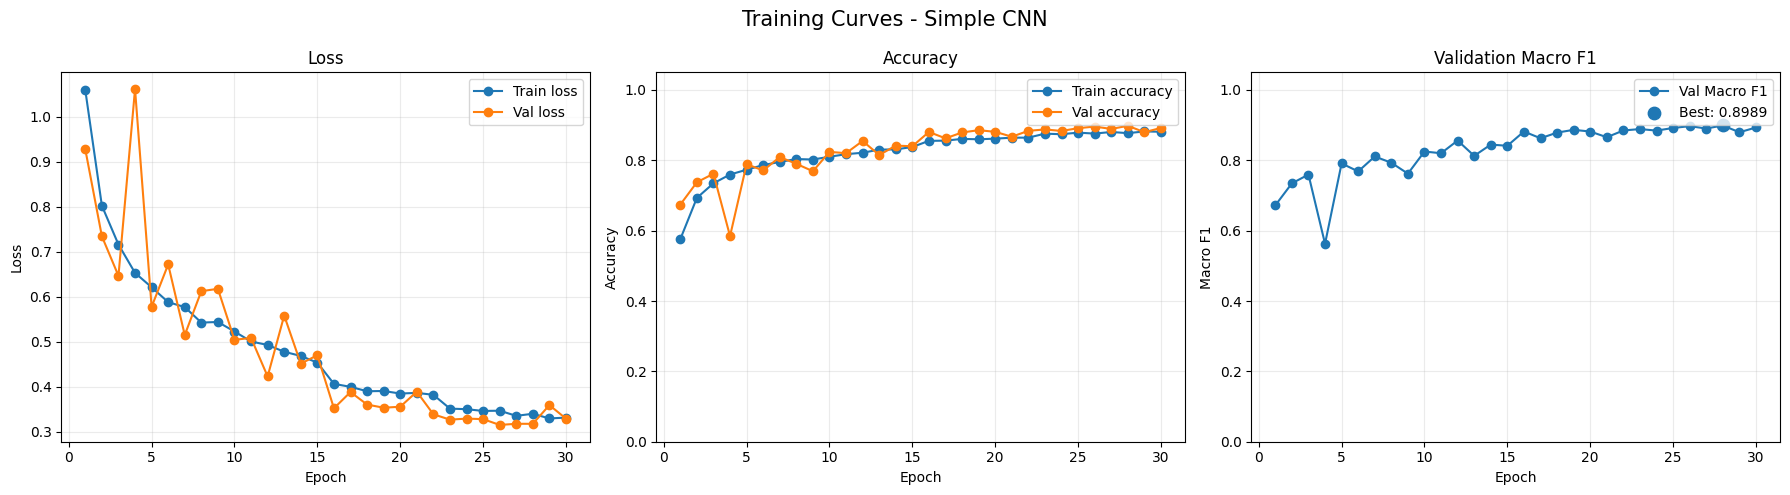

Plotting: ResNet18 Feature Extraction
Saved figure: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/figures/cs231/training_curves_resnet18_feature_extractor.png


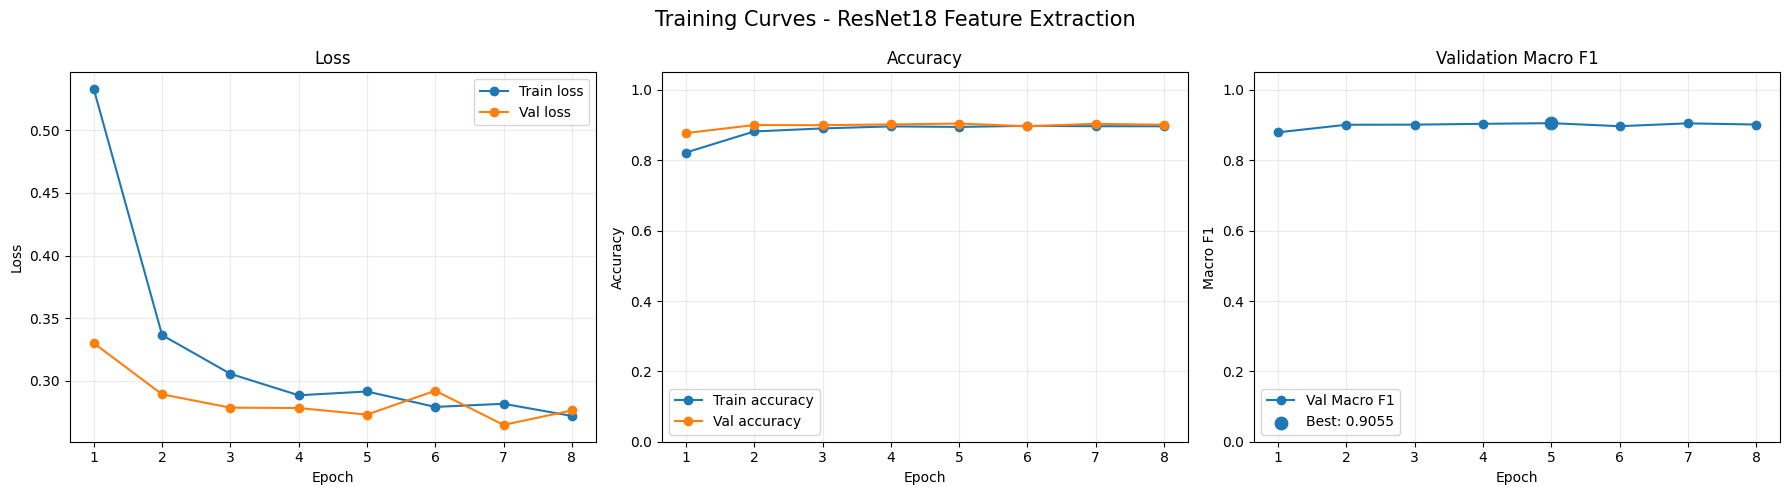

Plotting: ResNet18 Fine-tuned
Saved figure: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/figures/cs231/training_curves_resnet18_finetuned.png


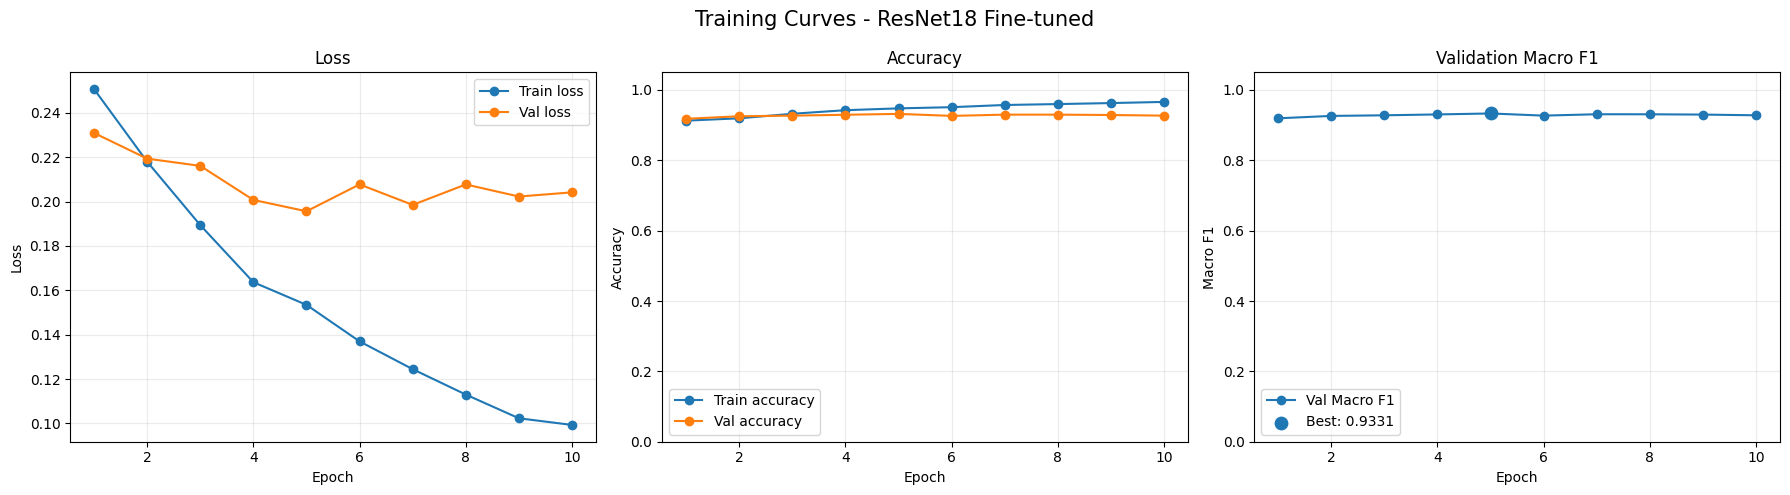

In [ ]:
def pick_column(df: pd.DataFrame, candidates: List[str]) -> Optional[str]:
    for col in candidates:
        if col in df.columns:
            return col
    return None


def plot_training_curves(model_key: str, history_df: pd.DataFrame) -> None:
    spec = MODEL_SPECS[model_key]
    model_name = spec["display_name"]

    epoch_col = pick_column(history_df, ["epoch", "Epoch"])
    if epoch_col is None:
        history_df = history_df.copy()
        history_df["epoch"] = np.arange(1, len(history_df) + 1)
        epoch_col = "epoch"

    train_loss_col = pick_column(history_df, ["train_loss", "loss_train"])
    val_loss_col = pick_column(history_df, ["val_loss", "valid_loss", "validation_loss"])
    train_acc_col = pick_column(history_df, ["train_accuracy", "train_acc"])
    val_acc_col = pick_column(history_df, ["val_accuracy", "val_acc", "valid_accuracy"])
    val_f1_col = pick_column(history_df, ["val_macro_f1", "valid_macro_f1", "macro_f1"])

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Loss
    if train_loss_col is not None:
        axes[0].plot(history_df[epoch_col], history_df[train_loss_col], marker="o", label="Train loss")
    if val_loss_col is not None:
        axes[0].plot(history_df[epoch_col], history_df[val_loss_col], marker="o", label="Val loss")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].grid(alpha=0.25)
    axes[0].legend()

    # Accuracy
    if train_acc_col is not None:
        axes[1].plot(history_df[epoch_col], history_df[train_acc_col], marker="o", label="Train accuracy")
    if val_acc_col is not None:
        axes[1].plot(history_df[epoch_col], history_df[val_acc_col], marker="o", label="Val accuracy")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_ylim(0, 1.05)
    axes[1].grid(alpha=0.25)
    axes[1].legend()

    # Validation Macro F1
    if val_f1_col is not None:
        axes[2].plot(history_df[epoch_col], history_df[val_f1_col], marker="o", label="Val Macro F1")
        best_idx = history_df[val_f1_col].astype(float).idxmax()
        best_epoch = history_df.loc[best_idx, epoch_col]
        best_f1 = history_df.loc[best_idx, val_f1_col]
        axes[2].scatter([best_epoch], [best_f1], s=80, label=f"Best: {best_f1:.4f}")
    axes[2].set_title("Validation Macro F1")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Macro F1")
    axes[2].set_ylim(0, 1.05)
    axes[2].grid(alpha=0.25)
    axes[2].legend()

    fig.suptitle(f"Training Curves - {model_name}", fontsize=15)
    save_path = FIGURE_DIR / f"training_curves_{model_key}.png"
    save_current_figure(save_path)
    plt.show()


for model_key, history_df in histories.items():
    print("Plotting:", MODEL_SPECS[model_key]["display_name"])
    plot_training_curves(model_key, history_df)


## 15. So sánh validation Macro F1 theo epoch giữa các model

Biểu đồ này cho thấy quá trình học của từng model và lợi ích của transfer learning.


Saved figure: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/figures/cs231/validation_macro_f1_all_models.png


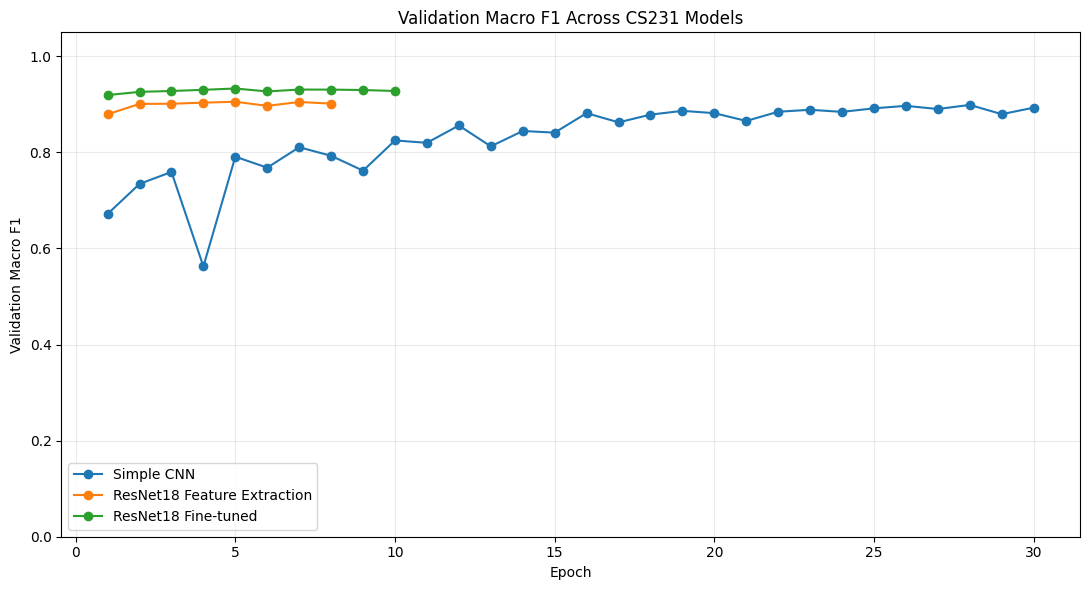

In [ ]:
plt.figure(figsize=(11, 6))

has_any_curve = False

for model_key, history_df in histories.items():
    epoch_col = pick_column(history_df, ["epoch", "Epoch"])
    val_f1_col = pick_column(history_df, ["val_macro_f1", "valid_macro_f1", "macro_f1"])

    if epoch_col is None:
        history_df = history_df.copy()
        history_df["epoch"] = np.arange(1, len(history_df) + 1)
        epoch_col = "epoch"

    if val_f1_col is not None:
        plt.plot(
            history_df[epoch_col],
            history_df[val_f1_col],
            marker="o",
            label=MODEL_SPECS[model_key]["display_name"]
        )
        has_any_curve = True

if has_any_curve:
    plt.xlabel("Epoch")
    plt.ylabel("Validation Macro F1")
    plt.title("Validation Macro F1 Across CS231 Models")
    plt.ylim(0, 1.05)
    plt.grid(alpha=0.25)
    plt.legend()
    save_current_figure(FIGURE_DIR / "validation_macro_f1_all_models.png")
    plt.show()
else:
    print("Không có history chứa val_macro_f1 để vẽ.")


## 16. Confusion matrix

Notebook tạo 2 loại confusion matrix:

- **Raw count**: số lượng ảnh nhầm tuyệt đối.
- **Normalized by true class**: tỷ lệ nhầm trong từng lớp thật, dễ dùng để phân tích báo cáo hơn.


Confusion matrix: Simple CNN
Saved figure: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/figures/cs231/simple_cnn_confusion_matrix_raw.png


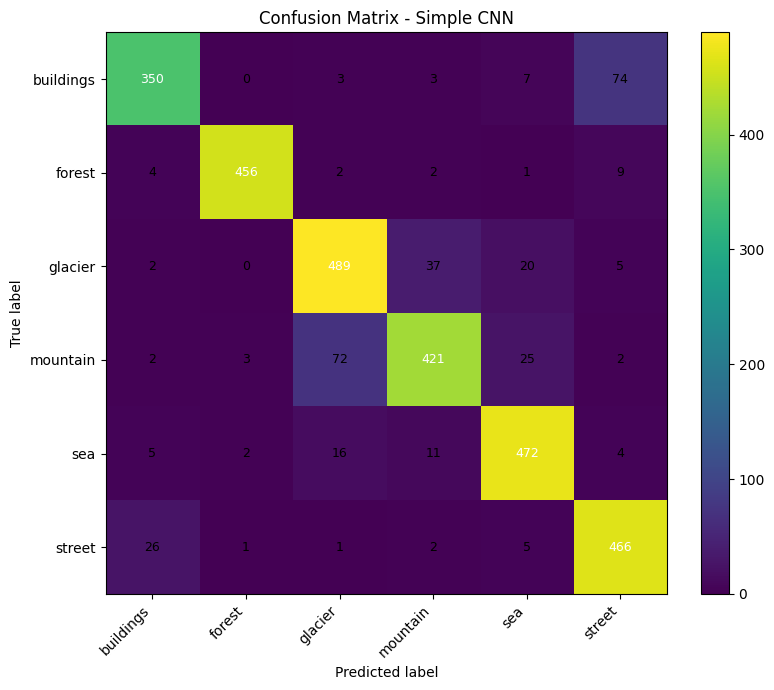

Saved: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/metrics/simple_cnn_confusion_matrix_raw.csv
Saved figure: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/figures/cs231/simple_cnn_confusion_matrix_normalized.png


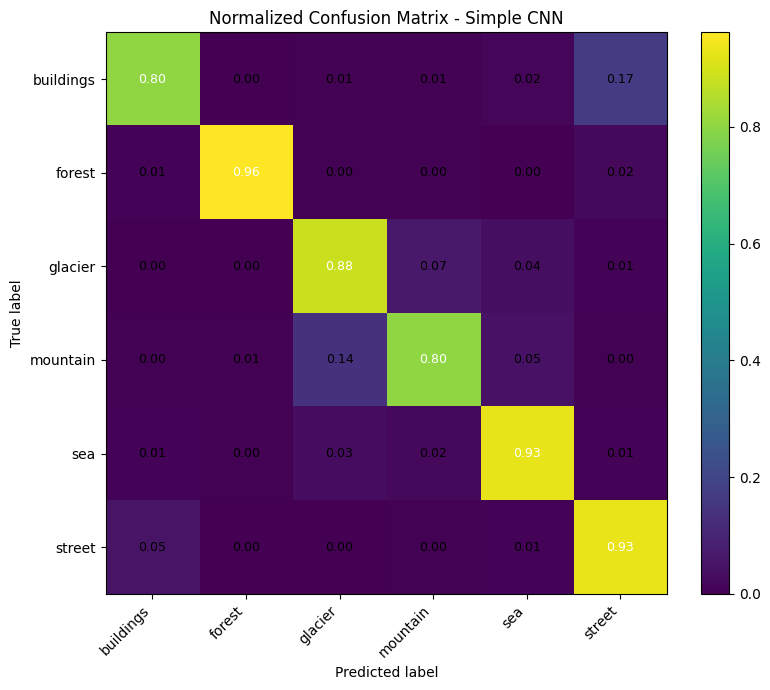

Saved: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/metrics/simple_cnn_confusion_matrix_normalized.csv
Confusion matrix: ResNet18 Feature Extraction
Saved figure: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/figures/cs231/resnet18_feature_extractor_confusion_matrix_raw.png


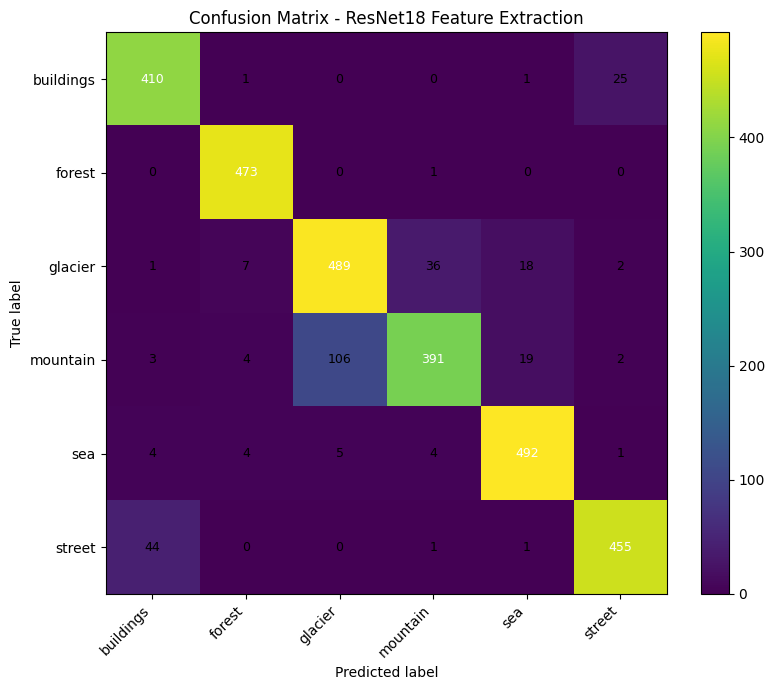

Saved: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/metrics/resnet18_feature_extractor_confusion_matrix_raw.csv
Saved figure: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/figures/cs231/resnet18_feature_extractor_confusion_matrix_normalized.png


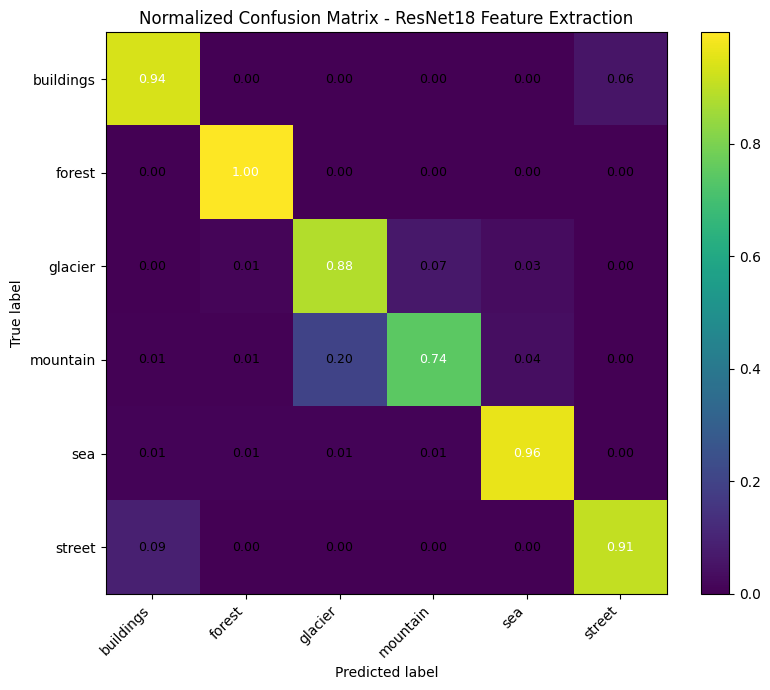

Saved: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/metrics/resnet18_feature_extractor_confusion_matrix_normalized.csv
Confusion matrix: ResNet18 Fine-tuned
Saved figure: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/figures/cs231/resnet18_finetuned_confusion_matrix_raw.png


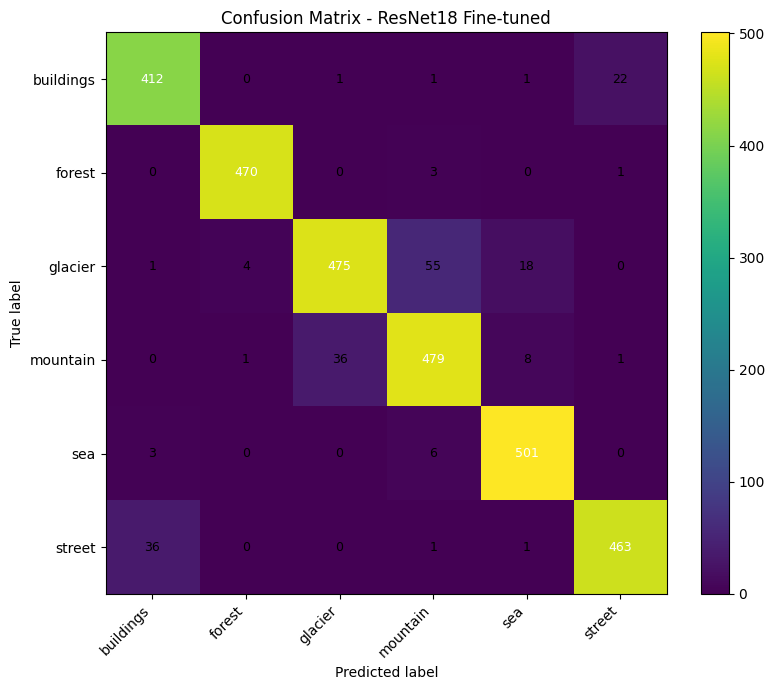

Saved: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/metrics/resnet18_finetuned_confusion_matrix_raw.csv
Saved figure: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/figures/cs231/resnet18_finetuned_confusion_matrix_normalized.png


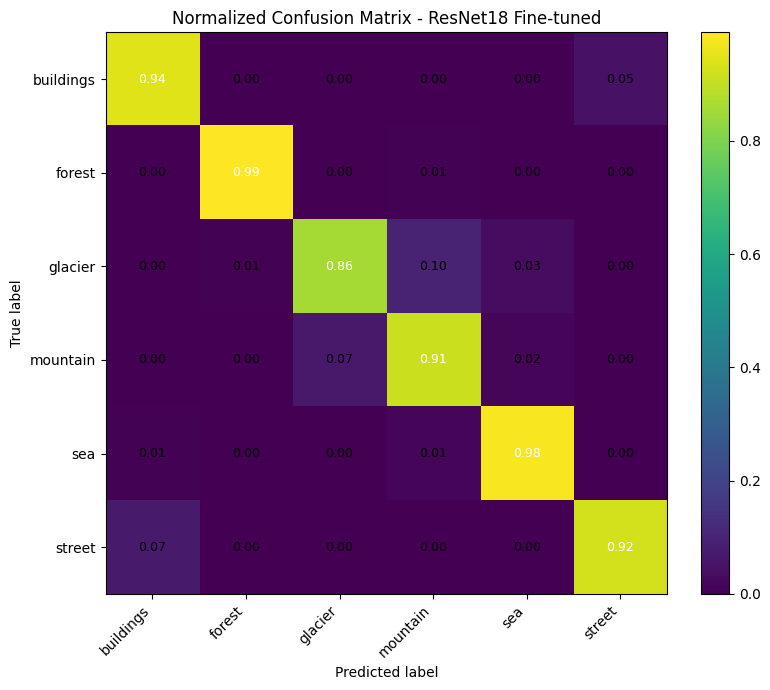

Saved: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/metrics/resnet18_finetuned_confusion_matrix_normalized.csv


In [ ]:
def plot_confusion_matrix_for_model(model_key: str, pred_df: pd.DataFrame, normalize: bool = False) -> pd.DataFrame:
    spec = MODEL_SPECS[model_key]
    model_name = spec["display_name"]

    y_true = pred_df["true_label_idx"].astype(int).values
    y_pred = pred_df["pred_label_idx"].astype(int).values

    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
    cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

    if normalize:
        cm_to_plot = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)
        fmt = ".2f"
        title = f"Normalized Confusion Matrix - {model_name}"
        file_suffix = "normalized"
    else:
        cm_to_plot = cm
        fmt = "d"
        title = f"Confusion Matrix - {model_name}"
        file_suffix = "raw"

    plt.figure(figsize=(9, 7))
    im = plt.imshow(cm_to_plot, interpolation="nearest")
    plt.title(title)
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.xticks(np.arange(NUM_CLASSES), class_names, rotation=45, ha="right")
    plt.yticks(np.arange(NUM_CLASSES), class_names)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")

    threshold = cm_to_plot.max() / 2.0 if cm_to_plot.size > 0 else 0

    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            value = cm_to_plot[i, j]
            text_value = format(value, fmt)
            plt.text(
                j,
                i,
                text_value,
                ha="center",
                va="center",
                color="white" if value > threshold else "black",
                fontsize=9
            )

    save_path = FIGURE_DIR / f"{model_key}_confusion_matrix_{file_suffix}.png"
    save_current_figure(save_path)
    plt.show()

    csv_path = METRIC_DIR / f"{model_key}_confusion_matrix_{file_suffix}.csv"

    if normalize:
        pd.DataFrame(cm_to_plot, index=class_names, columns=class_names).to_csv(csv_path)
    else:
        cm_df.to_csv(csv_path)

    print("Saved:", csv_path)
    return cm_df


confusion_matrices = {}

for model_key, pred_df in predictions.items():
    print("Confusion matrix:", MODEL_SPECS[model_key]["display_name"])
    confusion_matrices[model_key] = plot_confusion_matrix_for_model(model_key, pred_df, normalize=False)
    _ = plot_confusion_matrix_for_model(model_key, pred_df, normalize=True)


## 17. Top confused pairs

Bảng này trả lời câu hỏi: **model nhầm lớp nào sang lớp nào nhiều nhất?**

Đây là phần rất quan trọng cho phân tích lỗi trong báo cáo.


In [ ]:
def compute_top_confusions(pred_df: pd.DataFrame) -> pd.DataFrame:
    wrong_df = pred_df[~pred_df["is_correct"]].copy()

    if len(wrong_df) == 0:
        return pd.DataFrame(columns=["true_label", "pred_label", "count", "true_class_support", "rate_within_true_class"])

    true_support = pred_df["true_label"].value_counts().to_dict()

    grouped = (
        wrong_df
        .groupby(["true_label", "pred_label"])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
        .reset_index(drop=True)
    )

    grouped["true_class_support"] = grouped["true_label"].map(true_support)
    grouped["rate_within_true_class"] = grouped["count"] / grouped["true_class_support"]
    return grouped


top_confusion_tables = {}

for model_key, pred_df in predictions.items():
    top_conf_df = compute_top_confusions(pred_df)
    top_confusion_tables[model_key] = top_conf_df

    out_path = METRIC_DIR / f"{model_key}_top_confusions.csv"
    save_dataframe(top_conf_df, out_path)

    print("\nTop confusions -", MODEL_SPECS[model_key]["display_name"])
    display(top_conf_df.head(15))


Saved: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/metrics/simple_cnn_top_confusions.csv

Top confusions - Simple CNN


,true_label,pred_label,count,true_class_support,rate_within_true_class
0,buildings,street,74,437,0.169336
1,mountain,glacier,72,525,0.137143
2,glacier,mountain,37,553,0.066908
3,street,buildings,26,501,0.051896
4,mountain,sea,25,525,0.047619
5,glacier,sea,20,553,0.036166
6,sea,glacier,16,510,0.031373
7,sea,mountain,11,510,0.021569
8,forest,street,9,474,0.018987
9,buildings,sea,7,437,0.016018


Saved: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/metrics/resnet18_feature_extractor_top_confusions.csv

Top confusions - ResNet18 Feature Extraction


,true_label,pred_label,count,true_class_support,rate_within_true_class
0,mountain,glacier,106,525,0.201905
1,street,buildings,44,501,0.087824
2,glacier,mountain,36,553,0.065099
3,buildings,street,25,437,0.057208
4,mountain,sea,19,525,0.036190
5,glacier,sea,18,553,0.032550
6,glacier,forest,7,553,0.012658
7,sea,glacier,5,510,0.009804
8,mountain,forest,4,525,0.007619
9,sea,forest,4,510,0.007843


Saved: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/metrics/resnet18_finetuned_top_confusions.csv

Top confusions - ResNet18 Fine-tuned


,true_label,pred_label,count,true_class_support,rate_within_true_class
0,glacier,mountain,55,553,0.099458
1,mountain,glacier,36,525,0.068571
2,street,buildings,36,501,0.071856
3,buildings,street,22,437,0.050343
4,glacier,sea,18,553,0.032550
5,mountain,sea,8,525,0.015238
6,sea,mountain,6,510,0.011765
7,glacier,forest,4,553,0.007233
8,sea,buildings,3,510,0.005882
9,forest,mountain,3,474,0.006329


Saved figure: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/figures/cs231/simple_cnn_top_confused_pairs.png


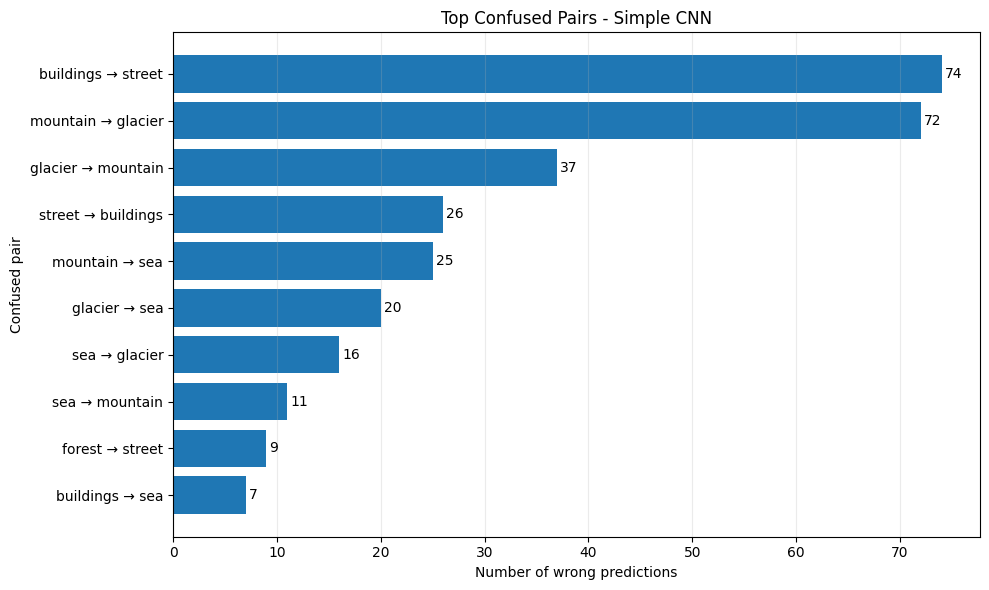

Saved figure: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/figures/cs231/resnet18_feature_extractor_top_confused_pairs.png


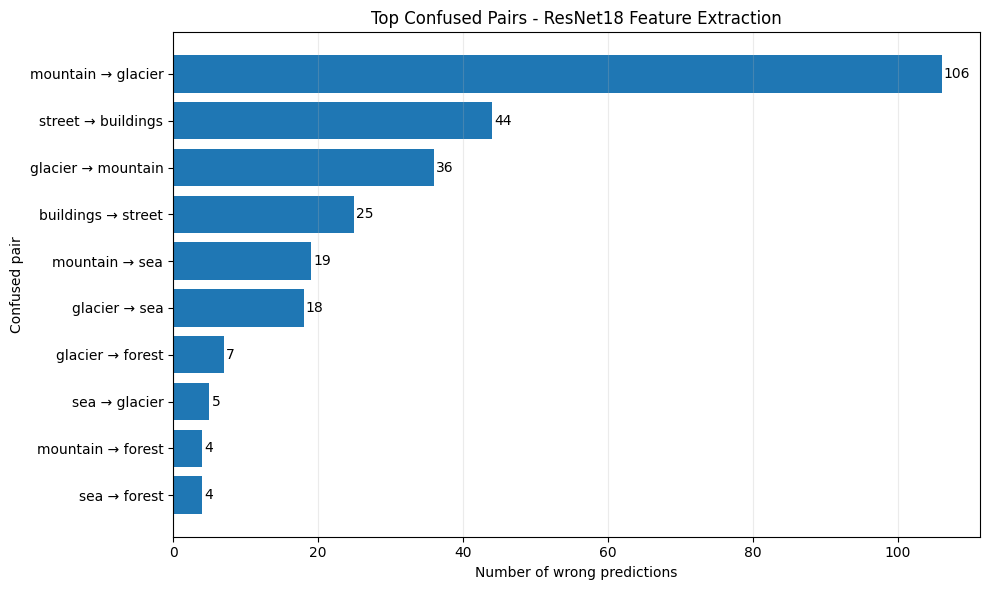

Saved figure: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/figures/cs231/resnet18_finetuned_top_confused_pairs.png


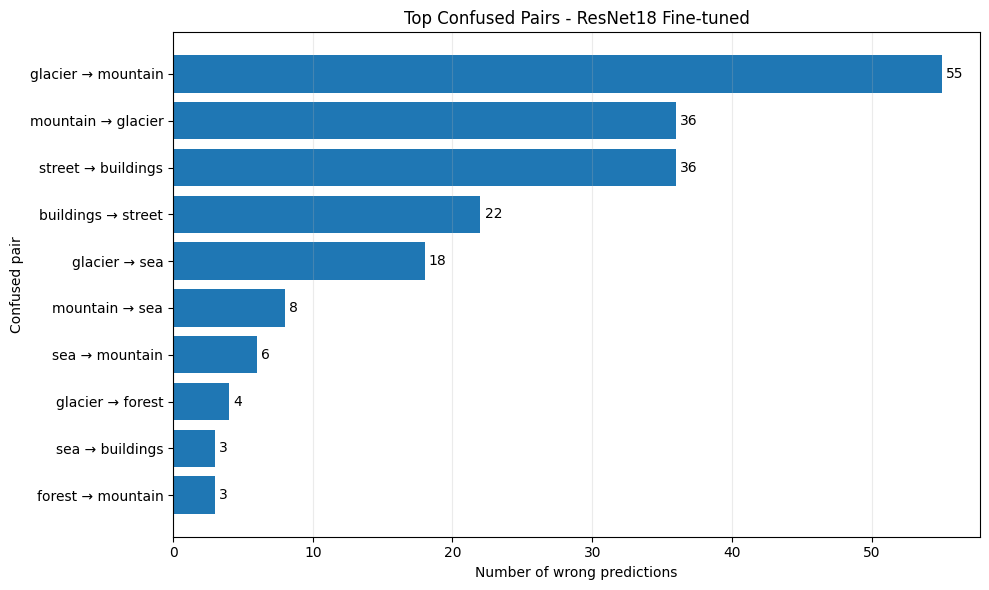

In [ ]:
def plot_top_confusions(model_key: str, top_conf_df: pd.DataFrame, top_n: int = 10) -> None:
    if len(top_conf_df) == 0:
        print("Không có lỗi dự đoán để vẽ:", model_key)
        return

    spec = MODEL_SPECS[model_key]
    plot_df = top_conf_df.head(top_n).copy()
    plot_df["pair"] = plot_df["true_label"] + " → " + plot_df["pred_label"]
    plot_df = plot_df.iloc[::-1]

    plt.figure(figsize=(10, 6))
    plt.barh(plot_df["pair"], plot_df["count"])
    plt.xlabel("Number of wrong predictions")
    plt.ylabel("Confused pair")
    plt.title(f"Top Confused Pairs - {spec['display_name']}")
    plt.grid(axis="x", alpha=0.25)

    for i, value in enumerate(plot_df["count"]):
        plt.text(value + 0.3, i, str(value), va="center")

    save_current_figure(FIGURE_DIR / f"{model_key}_top_confused_pairs.png")
    plt.show()


for model_key, top_conf_df in top_confusion_tables.items():
    plot_top_confusions(model_key, top_conf_df, top_n=10)


## 18. Per-class metrics

Phần này cho biết model mạnh/yếu ở lớp nào.


In [ ]:
def compute_per_class_metrics(pred_df: pd.DataFrame) -> pd.DataFrame:
    report = classification_report(
        pred_df["true_label_idx"].astype(int),
        pred_df["pred_label_idx"].astype(int),
        labels=list(range(NUM_CLASSES)),
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    df = pd.DataFrame(report).transpose()
    df = df.loc[class_names].reset_index().rename(columns={"index": "class_name"})
    return df


per_class_metric_rows = []

for model_key, pred_df in predictions.items():
    per_df = compute_per_class_metrics(pred_df)
    per_df["model_key"] = model_key
    per_df["model"] = MODEL_SPECS[model_key]["display_name"]
    per_class_metric_rows.append(per_df)

    save_dataframe(per_df, METRIC_DIR / f"{model_key}_per_class_metrics_recomputed.csv")
    print("\nPer-class metrics -", MODEL_SPECS[model_key]["display_name"])
    display(per_df)

all_per_class_df = pd.concat(per_class_metric_rows, ignore_index=True) if per_class_metric_rows else pd.DataFrame()
save_dataframe(all_per_class_df, METRIC_DIR / "cs231_all_models_per_class_metrics.csv")


Saved: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/metrics/simple_cnn_per_class_metrics_recomputed.csv

Per-class metrics - Simple CNN


,class_name,precision,recall,f1-score,support,model_key,model
0,buildings,0.899743,0.800915,0.847458,437.0,simple_cnn,Simple CNN
1,forest,0.987013,0.962025,0.974359,474.0,simple_cnn,Simple CNN
2,glacier,0.838765,0.884268,0.860915,553.0,simple_cnn,Simple CNN
3,mountain,0.884454,0.801905,0.841159,525.0,simple_cnn,Simple CNN
4,sea,0.890566,0.925490,0.907692,510.0,simple_cnn,Simple CNN
5,street,0.832143,0.930140,0.878417,501.0,simple_cnn,Simple CNN


Saved: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/metrics/resnet18_feature_extractor_per_class_metrics_recomputed.csv

Per-class metrics - ResNet18 Feature Extraction


,class_name,precision,recall,f1-score,support,model_key,model
0,buildings,0.887446,0.938215,0.912125,437.0,resnet18_feature_extractor,ResNet18 Feature Extraction
1,forest,0.967280,0.997890,0.982347,474.0,resnet18_feature_extractor,ResNet18 Feature Extraction
2,glacier,0.815000,0.884268,0.848222,553.0,resnet18_feature_extractor,ResNet18 Feature Extraction
3,mountain,0.903002,0.744762,0.816284,525.0,resnet18_feature_extractor,ResNet18 Feature Extraction
4,sea,0.926554,0.964706,0.945245,510.0,resnet18_feature_extractor,ResNet18 Feature Extraction
5,street,0.938144,0.908184,0.922921,501.0,resnet18_feature_extractor,ResNet18 Feature Extraction


Saved: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/metrics/resnet18_finetuned_per_class_metrics_recomputed.csv

Per-class metrics - ResNet18 Fine-tuned


,class_name,precision,recall,f1-score,support,model_key,model
0,buildings,0.911504,0.942792,0.926884,437.0,resnet18_finetuned,ResNet18 Fine-tuned
1,forest,0.989474,0.991561,0.990516,474.0,resnet18_finetuned,ResNet18 Fine-tuned
2,glacier,0.927734,0.858951,0.892019,553.0,resnet18_finetuned,ResNet18 Fine-tuned
3,mountain,0.878899,0.912381,0.895327,525.0,resnet18_finetuned,ResNet18 Fine-tuned
4,sea,0.947070,0.982353,0.964389,510.0,resnet18_finetuned,ResNet18 Fine-tuned
5,street,0.950719,0.924152,0.937247,501.0,resnet18_finetuned,ResNet18 Fine-tuned


Saved: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/metrics/cs231_all_models_per_class_metrics.csv


Saved figure: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/figures/cs231/per_class_f1_score_comparison.png


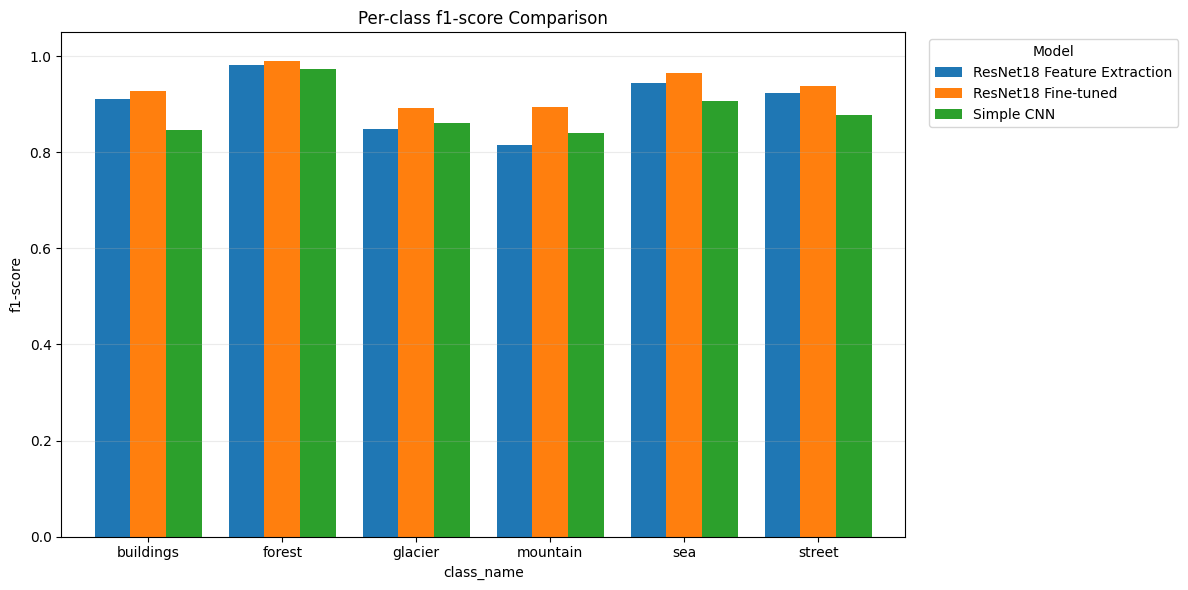

Saved figure: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/figures/cs231/per_class_precision_comparison.png


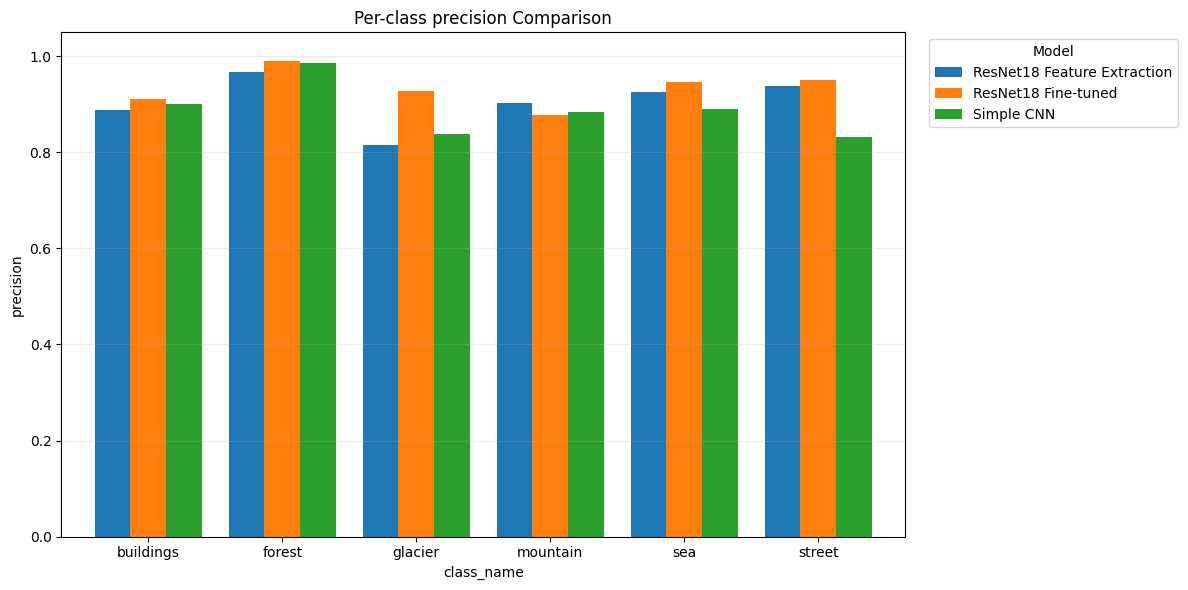

Saved figure: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/figures/cs231/per_class_recall_comparison.png


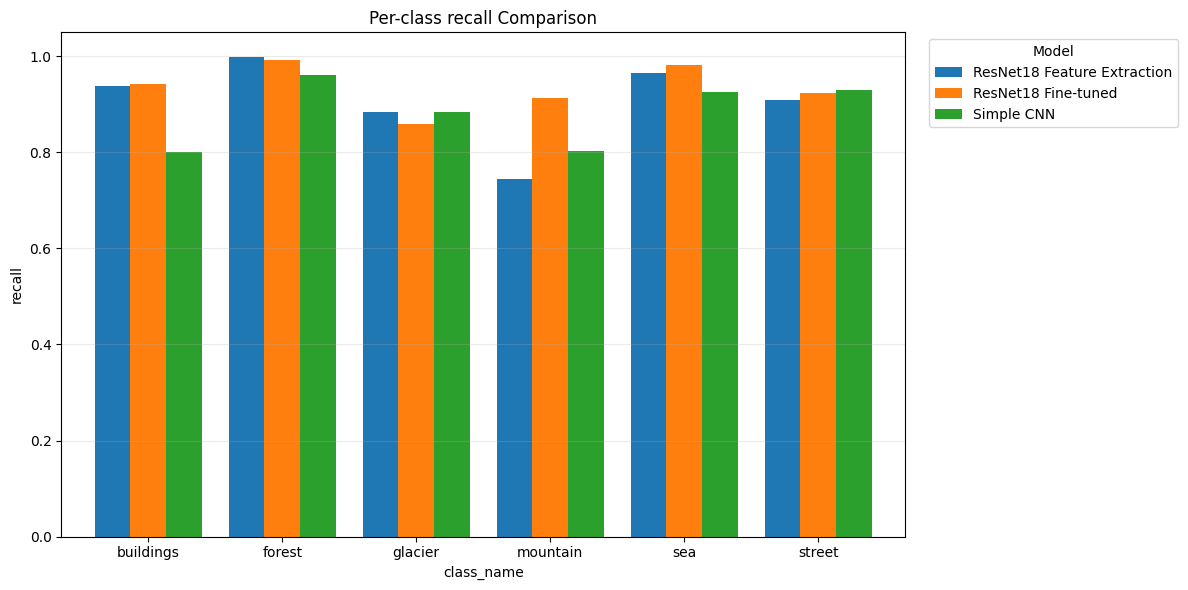

In [ ]:
def plot_per_class_metric(metric_name: str = "f1-score") -> None:
    if all_per_class_df.empty:
        print("Không có per-class metrics để vẽ.")
        return

    pivot_df = all_per_class_df.pivot(index="class_name", columns="model", values=metric_name)
    pivot_df = pivot_df.loc[class_names]

    ax = pivot_df.plot(kind="bar", figsize=(12, 6), width=0.8)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel(metric_name)
    ax.set_title(f"Per-class {metric_name} Comparison")
    ax.grid(axis="y", alpha=0.25)
    plt.xticks(rotation=0)
    plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")

    save_current_figure(FIGURE_DIR / f"per_class_{metric_name.replace('-', '_')}_comparison.png")
    plt.show()


plot_per_class_metric("f1-score")
plot_per_class_metric("precision")
plot_per_class_metric("recall")


## 19. Phân tích cải thiện giữa Simple CNN và ResNet18 Fine-tuned

Nếu có cả hai prediction file, cell này tính mức cải thiện theo từng lớp và toàn cục.


In [ ]:
if "simple_cnn" in predictions and "resnet18_finetuned" in predictions:
    simple_per = compute_per_class_metrics(predictions["simple_cnn"])
    resnet_per = compute_per_class_metrics(predictions["resnet18_finetuned"])

    improvement_df = simple_per[["class_name", "precision", "recall", "f1-score"]].merge(
        resnet_per[["class_name", "precision", "recall", "f1-score"]],
        on="class_name",
        suffixes=("_simple_cnn", "_resnet18_finetuned")
    )

    for metric_name in ["precision", "recall", "f1-score"]:
        improvement_df[f"delta_{metric_name}"] = (
            improvement_df[f"{metric_name}_resnet18_finetuned"]
            - improvement_df[f"{metric_name}_simple_cnn"]
        )

    display(improvement_df)
    save_dataframe(improvement_df, METRIC_DIR / "simple_cnn_vs_resnet18_finetuned_per_class_improvement.csv")

    simple_metrics = metrics["simple_cnn"]
    resnet_metrics = metrics["resnet18_finetuned"]

    overall_delta = {
        "accuracy_delta": resnet_metrics["accuracy"] - simple_metrics["accuracy"],
        "macro_f1_delta": resnet_metrics["macro_f1"] - simple_metrics["macro_f1"],
        "wrong_reduction": simple_metrics["num_wrong"] - resnet_metrics["num_wrong"],
    }

    display(overall_delta)
    save_json(overall_delta, METRIC_DIR / "simple_cnn_vs_resnet18_finetuned_overall_improvement.json")
else:
    print("Thiếu Simple CNN hoặc ResNet18 Fine-tuned prediction, bỏ qua phần so sánh cải thiện.")


,class_name,precision_simple_cnn,recall_simple_cnn,f1-score_simple_cnn,precision_resnet18_finetuned,recall_resnet18_finetuned,f1-score_resnet18_finetuned,delta_precision,delta_recall,delta_f1-score
0,buildings,0.899743,0.800915,0.847458,0.911504,0.942792,0.926884,0.011761,0.141876,0.079427
1,forest,0.987013,0.962025,0.974359,0.989474,0.991561,0.990516,0.002461,0.029536,0.016157
2,glacier,0.838765,0.884268,0.860915,0.927734,0.858951,0.892019,0.088969,-0.025316,0.031103
3,mountain,0.884454,0.801905,0.841159,0.878899,0.912381,0.895327,-0.005555,0.110476,0.054168
4,sea,0.890566,0.925490,0.907692,0.947070,0.982353,0.964389,0.056504,0.056863,0.056697
5,street,0.832143,0.930140,0.878417,0.950719,0.924152,0.937247,0.118576,-0.005988,0.058830


Saved: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/metrics/simple_cnn_vs_resnet18_finetuned_per_class_improvement.csv


{'accuracy_delta': 0.048666666666666636,
 'macro_f1_delta': 0.04939705369693537,
 'wrong_reduction': 146}

## 20. Hiển thị ảnh dự đoán sai

Notebook chọn các ảnh sai có **confidence cao nhất**. Đây là các lỗi đáng phân tích nhất vì model sai nhưng lại khá tự tin.


In [ ]:
def load_image_for_display(relative_path: str) -> Optional[Image.Image]:
    try:
        image_path = resolve_image_path(relative_path)
        return Image.open(image_path).convert("RGB")
    except Exception as e:
        print("Không đọc được ảnh:", relative_path, "|", repr(e))
        return None


def plot_misclassified_examples(model_key: str, pred_df: pd.DataFrame, top_n: int = 18) -> None:
    wrong_df = pred_df[~pred_df["is_correct"]].copy()

    if len(wrong_df) == 0:
        print("Không có ảnh sai cho model:", model_key)
        return

    if "confidence" in wrong_df.columns:
        wrong_df = wrong_df.sort_values("confidence", ascending=False)

    selected = wrong_df.head(top_n).reset_index(drop=True)

    n_cols = 3
    n_rows = int(np.ceil(len(selected) / n_cols))

    plt.figure(figsize=(5.2 * n_cols, 4.6 * n_rows))

    shown = 0

    for i, row in selected.iterrows():
        image = load_image_for_display(row["relative_path"])

        if image is None:
            continue

        shown += 1
        ax = plt.subplot(n_rows, n_cols, shown)
        ax.imshow(image)
        ax.axis("off")

        confidence = row.get("confidence", np.nan)
        confidence_text = f"conf={confidence:.3f}" if pd.notna(confidence) else "conf=N/A"
        ax.set_title(
            f"True: {row['true_label']}\nPred: {row['pred_label']} | {confidence_text}",
            fontsize=10
        )

    if shown == 0:
        print("Không hiển thị được ảnh nào cho model:", model_key)
        plt.close()
        return

    plt.suptitle(
        f"High-confidence Misclassified Examples - {MODEL_SPECS[model_key]['display_name']}",
        fontsize=15
    )

    save_current_figure(ERROR_FIGURE_DIR / f"{model_key}_misclassified_examples.png")
    plt.show()


for model_key, pred_df in predictions.items():
    plot_misclassified_examples(model_key, pred_df, top_n=NUM_MISCLASSIFIED_IMAGES)


Output hidden; open in https://colab.research.google.com to view.

## 21. Misclassified examples theo từng cặp nhầm quan trọng

Phần này hữu ích khi viết phân tích lỗi như `glacier → mountain`, `buildings → street`, ...


In [ ]:
def plot_examples_for_confusion_pair(
    model_key: str,
    pred_df: pd.DataFrame,
    true_label: str,
    pred_label: str,
    max_images: int = 9
) -> None:
    pair_df = pred_df[
        (pred_df["true_label"] == true_label)
        & (pred_df["pred_label"] == pred_label)
    ].copy()

    if len(pair_df) == 0:
        print(f"Không có cặp nhầm {true_label} -> {pred_label} cho {model_key}")
        return

    if "confidence" in pair_df.columns:
        pair_df = pair_df.sort_values("confidence", ascending=False)

    selected = pair_df.head(max_images).reset_index(drop=True)

    n_cols = 3
    n_rows = int(np.ceil(len(selected) / n_cols))
    plt.figure(figsize=(5 * n_cols, 4.5 * n_rows))

    shown = 0

    for i, row in selected.iterrows():
        image = load_image_for_display(row["relative_path"])
        if image is None:
            continue

        shown += 1
        ax = plt.subplot(n_rows, n_cols, shown)
        ax.imshow(image)
        ax.axis("off")
        conf = row.get("confidence", np.nan)
        conf_text = f"conf={conf:.3f}" if pd.notna(conf) else "conf=N/A"
        ax.set_title(conf_text, fontsize=10)

    if shown == 0:
        plt.close()
        return

    plt.suptitle(
        f"{MODEL_SPECS[model_key]['display_name']}: {true_label} → {pred_label}",
        fontsize=15
    )

    safe_pair = f"{true_label}_to_{pred_label}".replace("/", "_")
    save_path = ERROR_FIGURE_DIR / f"{model_key}_{safe_pair}_examples.png"
    save_current_figure(save_path)
    plt.show()


# Tự động lấy 3 cặp nhầm nhiều nhất của ResNet18 Fine-tuned nếu có.
main_model_key = "resnet18_finetuned" if "resnet18_finetuned" in predictions else None

if main_model_key is not None and main_model_key in top_confusion_tables:
    top_pairs = top_confusion_tables[main_model_key].head(3)

    for _, row in top_pairs.iterrows():
        plot_examples_for_confusion_pair(
            main_model_key,
            predictions[main_model_key],
            true_label=row["true_label"],
            pred_label=row["pred_label"],
            max_images=9
        )
else:
    print("Không tìm thấy ResNet18 Fine-tuned để vẽ lỗi theo cặp.")


Output hidden; open in https://colab.research.google.com to view.

## 22. Phân tích confidence

Mục tiêu:

- Sai nhưng confidence cao: lỗi nguy hiểm, model rất tự tin dù sai.
- Sai nhưng confidence thấp: model phân vân, có thể do ảnh mơ hồ.


Saved figure: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/figures/cs231/simple_cnn_confidence_distribution.png


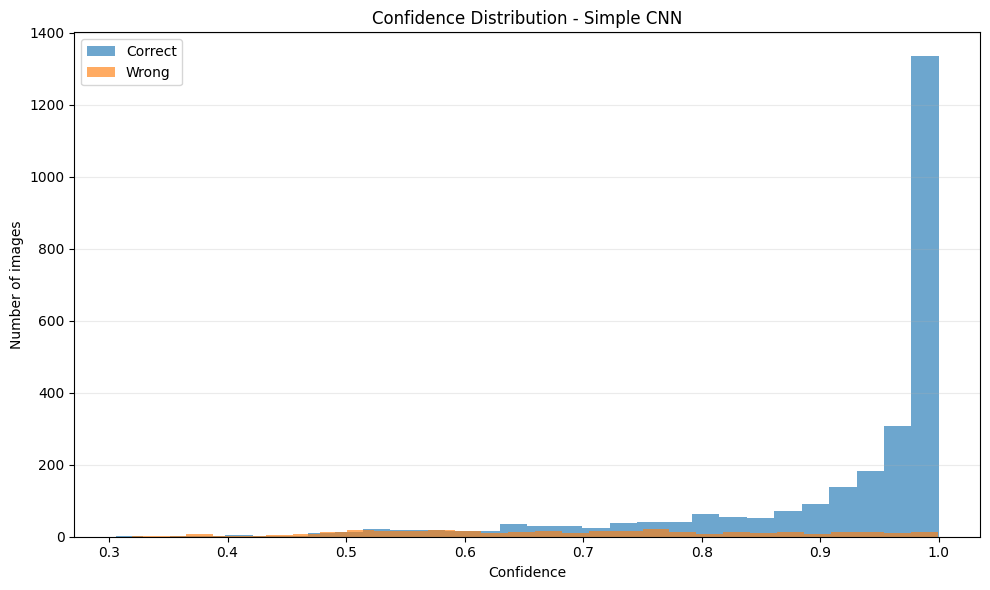

Saved figure: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/figures/cs231/resnet18_feature_extractor_confidence_distribution.png


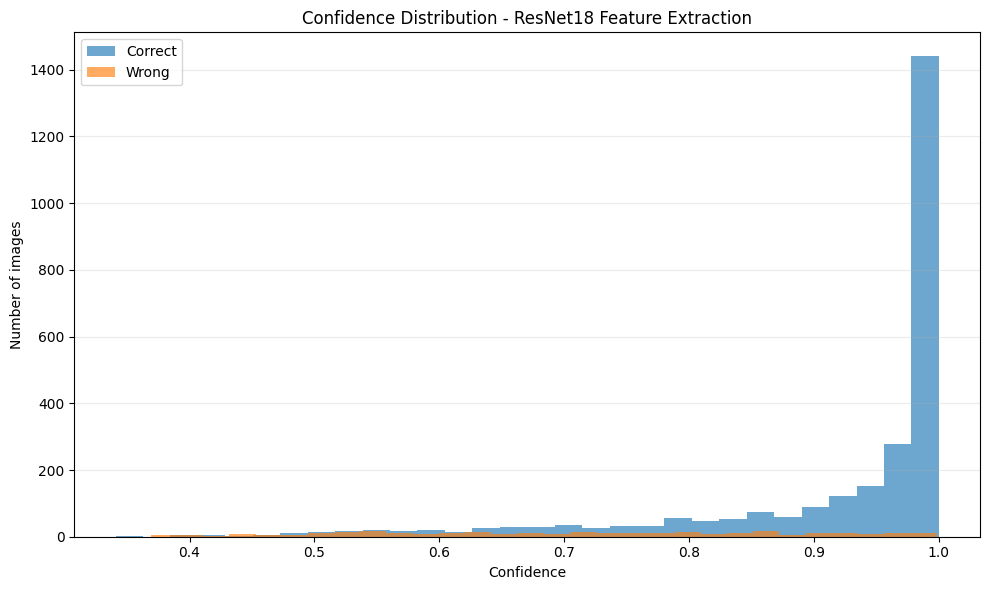

Saved figure: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/figures/cs231/resnet18_finetuned_confidence_distribution.png


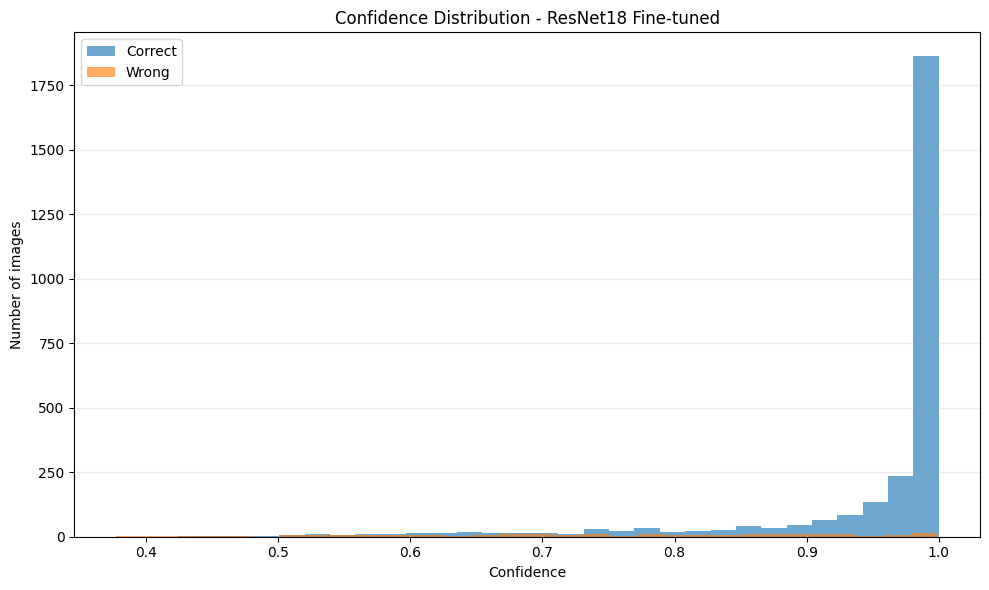

,model,correct_conf_mean,correct_conf_median,wrong_conf_mean,wrong_conf_median,high_conf_wrong_0_9,high_conf_wrong_0_8
0,Simple CNN,0.919474,0.977426,0.694869,0.696451,55,95
1,ResNet18 Feature Extraction,0.922565,0.983494,0.706756,0.713092,44,93
2,ResNet18 Fine-tuned,0.952385,0.995360,0.749580,0.755547,45,84


Saved: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/metrics/cs231_confidence_analysis.csv


In [ ]:
def plot_confidence_distribution(model_key: str, pred_df: pd.DataFrame) -> None:
    if "confidence" not in pred_df.columns or pred_df["confidence"].isna().all():
        print("Không có confidence để vẽ:", model_key)
        return

    correct_conf = pred_df[pred_df["is_correct"]]["confidence"].dropna()
    wrong_conf = pred_df[~pred_df["is_correct"]]["confidence"].dropna()

    plt.figure(figsize=(10, 6))
    plt.hist(correct_conf, bins=30, alpha=0.65, label="Correct")
    plt.hist(wrong_conf, bins=30, alpha=0.65, label="Wrong")
    plt.xlabel("Confidence")
    plt.ylabel("Number of images")
    plt.title(f"Confidence Distribution - {MODEL_SPECS[model_key]['display_name']}")
    plt.grid(axis="y", alpha=0.25)
    plt.legend()

    save_current_figure(FIGURE_DIR / f"{model_key}_confidence_distribution.png")
    plt.show()


confidence_summary_rows = []

for model_key, pred_df in predictions.items():
    if "confidence" not in pred_df.columns or pred_df["confidence"].isna().all():
        continue

    correct_df = pred_df[pred_df["is_correct"]]
    wrong_df = pred_df[~pred_df["is_correct"]]

    confidence_summary_rows.append({
        "model": MODEL_SPECS[model_key]["display_name"],
        "correct_conf_mean": correct_df["confidence"].mean(),
        "correct_conf_median": correct_df["confidence"].median(),
        "wrong_conf_mean": wrong_df["confidence"].mean(),
        "wrong_conf_median": wrong_df["confidence"].median(),
        "high_conf_wrong_0_9": int((wrong_df["confidence"] >= 0.9).sum()),
        "high_conf_wrong_0_8": int((wrong_df["confidence"] >= 0.8).sum()),
    })

    plot_confidence_distribution(model_key, pred_df)

confidence_summary_df = pd.DataFrame(confidence_summary_rows)
display(confidence_summary_df)
save_dataframe(confidence_summary_df, METRIC_DIR / "cs231_confidence_analysis.csv")


## 23. Grad-CAM cho Simple CNN và ResNet18 Fine-tuned

Phần này bổ sung **Grad-CAM** cho **cả Simple CNN và ResNet18 Fine-tuned**.

Mục tiêu:

- trực quan hóa vùng ảnh mà model chú ý khi phân loại;
- phân tích các ảnh **dự đoán đúng** và **dự đoán sai**;
- hỗ trợ phần giải thích mô hình trong báo cáo CS231.

Trong notebook này:

- **Simple CNN** dùng như baseline CNN học từ đầu;
- **ResNet18 Fine-tuned** dùng như model chính của CS231.


In [ ]:
# =========================
# GRAD-CAM CONFIG
# =========================

GRADCAM_DIR = FIGURE_DIR / "gradcam"
GRADCAM_DIR.mkdir(parents=True, exist_ok=True)

GRADCAM_MODEL_KEYS = ["simple_cnn", "resnet18_finetuned"]
GRADCAM_NUM_CORRECT = 6
GRADCAM_NUM_WRONG = 6
GRADCAM_OVERLAY_ALPHA = 0.42

print("Grad-CAM output dir:", GRADCAM_DIR)
print("Grad-CAM models:", GRADCAM_MODEL_KEYS)


Grad-CAM output dir: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/figures/cs231/gradcam
Grad-CAM models: ['simple_cnn', 'resnet18_finetuned']


In [ ]:
# =========================
# GRAD-CAM HELPERS
# =========================

import matplotlib.cm as mpl_cm


def get_checkpoint_path_for_model(model_key: str) -> Path:
    checkpoint_map = {
        "simple_cnn": MODEL_DIR / "simple_cnn_best.pth",
        "resnet18_finetuned": MODEL_DIR / "resnet18_finetuned_best.pth",
        "resnet18_feature_extractor": MODEL_DIR / "resnet18_feature_extractor_best.pth",
    }
    return checkpoint_map[model_key]



def get_eval_transform_for_model(model_key: str):
    if model_key == "simple_cnn":
        return simple_eval_transform
    return transfer_eval_transform



def build_model_for_gradcam(model_key: str, device: torch.device):
    if model_key == "simple_cnn":
        model = SimpleCNN(num_classes=NUM_CLASSES)
    elif model_key in ["resnet18_finetuned", "resnet18_feature_extractor"]:
        model = create_resnet18(num_classes=NUM_CLASSES, pretrained=False)
    else:
        raise ValueError(f"Unsupported model for Grad-CAM: {model_key}")

    checkpoint_path = get_checkpoint_path_for_model(model_key)
    if not checkpoint_path.exists():
        raise FileNotFoundError(f"Không tìm thấy checkpoint: {checkpoint_path}")

    checkpoint = load_model_state(model, checkpoint_path, device)
    model = model.to(device)
    model.eval()
    return model, checkpoint, checkpoint_path



def get_target_layer(model_key: str, model: nn.Module):
    if model_key == "simple_cnn":
        # Conv2d cuối cùng trong Simple CNN
        return model.features[12]
    elif model_key in ["resnet18_finetuned", "resnet18_feature_extractor"]:
        # Convolution sâu cuối của ResNet18
        return model.layer4[-1].conv2
    else:
        raise ValueError(f"Không xác định được target layer cho {model_key}")


class GradCAM:
    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.forward_handle = None
        self.backward_handle = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, inputs, output):
            self.activations = output.detach()

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        self.forward_handle = self.target_layer.register_forward_hook(forward_hook)
        self.backward_handle = self.target_layer.register_full_backward_hook(backward_hook)

    def remove_hooks(self):
        if self.forward_handle is not None:
            self.forward_handle.remove()
        if self.backward_handle is not None:
            self.backward_handle.remove()

    def generate(self, input_tensor: torch.Tensor, target_class_idx: Optional[int] = None):
        self.model.zero_grad(set_to_none=True)

        logits = self.model(input_tensor)
        probs = torch.softmax(logits, dim=1)
        pred_idx = int(torch.argmax(probs, dim=1).item())
        pred_conf = float(torch.max(probs, dim=1).values.item())

        if target_class_idx is None:
            target_class_idx = pred_idx

        score = logits[:, target_class_idx].sum()
        score.backward(retain_graph=True)

        if self.activations is None or self.gradients is None:
            raise RuntimeError("Grad-CAM hooks không thu được activation/gradient.")

        activations = self.activations
        gradients = self.gradients
        weights = gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * activations).sum(dim=1)
        cam = torch.relu(cam)
        cam = cam[0].detach().cpu().numpy()

        cam = cam - cam.min()
        max_value = cam.max()
        if max_value > 0:
            cam = cam / max_value

        return {
            "logits": logits.detach().cpu(),
            "probabilities": probs.detach().cpu(),
            "pred_idx": pred_idx,
            "pred_label": idx_to_class[pred_idx],
            "pred_confidence": pred_conf,
            "target_class_idx": int(target_class_idx),
            "target_label": idx_to_class[int(target_class_idx)],
            "cam": cam,
        }



def cam_to_heatmap_image(cam: np.ndarray, output_size: tuple) -> Image.Image:
    cam_uint8 = np.uint8(np.clip(cam, 0, 1) * 255)
    heat = Image.fromarray(cam_uint8).resize(output_size, resample=Image.BILINEAR)
    heat_np = np.array(heat).astype(np.float32) / 255.0
    colored = mpl_cm.jet(heat_np)[..., :3]
    colored_uint8 = np.uint8(np.clip(colored, 0, 1) * 255)
    return Image.fromarray(colored_uint8)



def overlay_heatmap_on_image(image: Image.Image, heatmap_image: Image.Image, alpha: float = 0.42) -> Image.Image:
    image_np = np.array(image).astype(np.float32) / 255.0
    heatmap_np = np.array(heatmap_image).astype(np.float32) / 255.0
    overlay = np.clip((1 - alpha) * image_np + alpha * heatmap_np, 0, 1)
    return Image.fromarray(np.uint8(overlay * 255))



def load_pil_and_tensor_for_gradcam(relative_path: str, model_key: str, device: torch.device):
    image_path = resolve_image_path(relative_path)
    pil_image = Image.open(image_path).convert("RGB")
    transform = get_eval_transform_for_model(model_key)
    input_tensor = transform(pil_image).unsqueeze(0).to(device)
    return pil_image, input_tensor, image_path



def select_diverse_correct_examples(pred_df: pd.DataFrame, num_samples: int = 6) -> pd.DataFrame:
    correct_df = pred_df[pred_df["is_correct"]].copy()
    if len(correct_df) == 0:
        return correct_df

    if "confidence" in correct_df.columns:
        correct_df = correct_df.sort_values("confidence", ascending=False)

    selected_parts = []
    used_indices = set()

    # Cố gắng lấy mỗi lớp một ảnh đúng có confidence cao
    for cls in class_names:
        cls_df = correct_df[correct_df["true_label"] == cls]
        if len(cls_df) == 0:
            continue
        row = cls_df.iloc[0]
        selected_parts.append(row)
        used_indices.add(row.name)
        if len(selected_parts) >= num_samples:
            break

    if len(selected_parts) < num_samples:
        remainder = correct_df.loc[~correct_df.index.isin(used_indices)]
        need = num_samples - len(selected_parts)
        if need > 0 and len(remainder) > 0:
            selected_parts.extend([row for _, row in remainder.head(need).iterrows()])

    if not selected_parts:
        return correct_df.head(0)

    return pd.DataFrame(selected_parts).reset_index(drop=True)



def select_diverse_wrong_examples(pred_df: pd.DataFrame, num_samples: int = 6) -> pd.DataFrame:
    wrong_df = pred_df[~pred_df["is_correct"]].copy()
    if len(wrong_df) == 0:
        return wrong_df

    wrong_df["confusion_pair"] = wrong_df["true_label"].astype(str) + " → " + wrong_df["pred_label"].astype(str)

    if "confidence" in wrong_df.columns:
        wrong_df = wrong_df.sort_values("confidence", ascending=False)

    selected_parts = []
    used_pairs = set()
    used_indices = set()

    for _, row in wrong_df.iterrows():
        pair = row["confusion_pair"]
        if pair in used_pairs:
            continue
        selected_parts.append(row)
        used_pairs.add(pair)
        used_indices.add(row.name)
        if len(selected_parts) >= num_samples:
            break

    if len(selected_parts) < num_samples:
        remainder = wrong_df.loc[~wrong_df.index.isin(used_indices)]
        need = num_samples - len(selected_parts)
        if need > 0 and len(remainder) > 0:
            selected_parts.extend([row for _, row in remainder.head(need).iterrows()])

    if not selected_parts:
        return wrong_df.head(0)

    return pd.DataFrame(selected_parts).reset_index(drop=True)


print("Grad-CAM helper functions ready.")


Grad-CAM helper functions ready.


In [ ]:
# =========================
# BUILD MODELS FOR GRAD-CAM
# =========================

gradcam_models = {}
gradcam_objects = {}
gradcam_checkpoints = {}

for model_key in GRADCAM_MODEL_KEYS:
    try:
        model, checkpoint, checkpoint_path = build_model_for_gradcam(model_key, DEVICE)
        target_layer = get_target_layer(model_key, model)
        gradcam = GradCAM(model, target_layer)

        gradcam_models[model_key] = model
        gradcam_objects[model_key] = gradcam
        gradcam_checkpoints[model_key] = {
            "checkpoint": checkpoint,
            "checkpoint_path": str(checkpoint_path),
            "target_layer": str(target_layer),
        }

        print(f"Grad-CAM ready: {model_key}")
        print("  checkpoint:", checkpoint_path)
        print("  target_layer:", target_layer)
    except Exception as e:
        print(f"Không thể chuẩn bị Grad-CAM cho {model_key}: {repr(e)}")

print("Grad-CAM models loaded:", list(gradcam_models.keys()))


Grad-CAM ready: simple_cnn
  checkpoint: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/models/cs231/simple_cnn_best.pth
  target_layer: Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
Grad-CAM ready: resnet18_finetuned
  checkpoint: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/models/cs231/resnet18_finetuned_best.pth
  target_layer: Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
Grad-CAM models loaded: ['simple_cnn', 'resnet18_finetuned']


### 23.1. Grad-CAM cho ảnh dự đoán đúng

Chiến lược chọn mẫu:

- ưu tiên ảnh **đúng** có confidence cao;
- cố gắng đa dạng các lớp;
- với mỗi ảnh sẽ hiển thị:
  - ảnh gốc,
  - heatmap Grad-CAM,
  - ảnh overlay (ảnh gốc + heatmap).


In [ ]:
def plot_gradcam_correct_examples(model_key: str, pred_df: pd.DataFrame, num_samples: int = 6) -> Optional[pd.DataFrame]:
    if model_key not in gradcam_objects:
        print("Grad-CAM chưa sẵn sàng cho model:", model_key)
        return None

    selected_df = select_diverse_correct_examples(pred_df, num_samples=num_samples)
    if len(selected_df) == 0:
        print("Không có ảnh đúng để vẽ Grad-CAM cho model:", model_key)
        return None

    gradcam = gradcam_objects[model_key]
    model_name = MODEL_SPECS[model_key]["display_name"]
    save_rows = []

    n_rows = len(selected_df)
    n_cols = 3

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(18, 5.2 * n_rows),
        constrained_layout=True
    )

    if n_rows == 1:
        axes = np.array([axes])

    for plot_idx, (_, row) in enumerate(selected_df.iterrows()):
        pil_image, input_tensor, image_path = load_pil_and_tensor_for_gradcam(
            row["relative_path"], model_key, DEVICE
        )

        result = gradcam.generate(input_tensor, target_class_idx=int(row["pred_label_idx"]))
        heatmap_image = cam_to_heatmap_image(result["cam"], pil_image.size)
        overlay_image = overlay_heatmap_on_image(
            pil_image, heatmap_image, alpha=GRADCAM_OVERLAY_ALPHA
        )

        # ===== Text hiển thị =====
        csv_conf_text = ""
        if pd.notna(row.get("confidence", np.nan)):
            csv_conf_text = f"CSV conf: {float(row['confidence']):.3f} | "

        model_conf_text = f"Model conf: {result['pred_confidence']:.3f}"

        # ===== Cột 1: ảnh gốc =====
        axes[plot_idx, 0].imshow(pil_image)
        axes[plot_idx, 0].axis("off")
        axes[plot_idx, 0].set_title(
            f"Original\nTrue: {row['true_label']} | Pred: {row['pred_label']}",
            fontsize=11,
            pad=10
        )
        axes[plot_idx, 0].set_xlabel(
            f"{csv_conf_text}{model_conf_text}",
            fontsize=10,
            labelpad=8
        )

        # ===== Cột 2: heatmap =====
        axes[plot_idx, 1].imshow(heatmap_image)
        axes[plot_idx, 1].axis("off")
        axes[plot_idx, 1].set_title(
            f"Grad-CAM Heatmap\nTarget class: {result['target_label']}",
            fontsize=11,
            pad=10
        )

        # ===== Cột 3: overlay =====
        axes[plot_idx, 2].imshow(overlay_image)
        axes[plot_idx, 2].axis("off")
        axes[plot_idx, 2].set_title(
            f"Overlay\nTarget class: {result['target_label']}",
            fontsize=11,
            pad=10
        )

        save_rows.append({
            "relative_path": row["relative_path"],
            "image_path": str(image_path),
            "true_label": row["true_label"],
            "pred_label": row["pred_label"],
            "csv_confidence": row.get("confidence", np.nan),
            "model_confidence": result["pred_confidence"],
            "selection_type": "correct",
            "target_label": result["target_label"],
        })

    fig.suptitle(
        f"Grad-CAM - Correct Examples - {model_name}",
        fontsize=16,
        y=1.02
    )

    save_path = GRADCAM_DIR / f"{model_key}_gradcam_correct_examples.png"
    save_current_figure(save_path)
    plt.show()

    selected_out_df = pd.DataFrame(save_rows)
    save_dataframe(selected_out_df, METRIC_DIR / f"{model_key}_gradcam_correct_examples.csv")
    return selected_out_df


gradcam_correct_tables = {}

for model_key in GRADCAM_MODEL_KEYS:
    if model_key in predictions:
        out_df = plot_gradcam_correct_examples(model_key, predictions[model_key], num_samples=GRADCAM_NUM_CORRECT)
        if out_df is not None:
            gradcam_correct_tables[model_key] = out_df


Output hidden; open in https://colab.research.google.com to view.

### 23.2. Grad-CAM cho ảnh dự đoán sai

Với ảnh dự đoán sai, notebook hiển thị:

- ảnh gốc,
- **overlay cho lớp dự đoán** (`predicted class`),
- **overlay cho lớp đúng** (`true class`).

Cách hiển thị này giúp bạn phân tích:

- model đang chú ý vào đâu khi ra quyết định sai;
- nếu ép nhìn theo `true class`, vùng kích hoạt có khác gì không.


In [ ]:
def plot_gradcam_wrong_examples(model_key: str, pred_df: pd.DataFrame, num_samples: int = 6) -> Optional[pd.DataFrame]:
    if model_key not in gradcam_objects:
        print("Grad-CAM chưa sẵn sàng cho model:", model_key)
        return None

    selected_df = select_diverse_wrong_examples(pred_df, num_samples=num_samples)
    if len(selected_df) == 0:
        print("Không có ảnh sai để vẽ Grad-CAM cho model:", model_key)
        return None

    gradcam = gradcam_objects[model_key]
    model_name = MODEL_SPECS[model_key]["display_name"]
    save_rows = []

    n_rows = len(selected_df)
    n_cols = 3

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(18, 5.5 * n_rows),
        constrained_layout=True
    )

    if n_rows == 1:
        axes = np.array([axes])

    for plot_idx, (_, row) in enumerate(selected_df.iterrows()):
        pil_image, input_tensor, image_path = load_pil_and_tensor_for_gradcam(
            row["relative_path"], model_key, DEVICE
        )

        pred_result = gradcam.generate(input_tensor, target_class_idx=int(row["pred_label_idx"]))
        pred_heatmap = cam_to_heatmap_image(pred_result["cam"], pil_image.size)
        pred_overlay = overlay_heatmap_on_image(
            pil_image, pred_heatmap, alpha=GRADCAM_OVERLAY_ALPHA
        )

        true_result = gradcam.generate(input_tensor, target_class_idx=int(row["true_label_idx"]))
        true_heatmap = cam_to_heatmap_image(true_result["cam"], pil_image.size)
        true_overlay = overlay_heatmap_on_image(
            pil_image, true_heatmap, alpha=GRADCAM_OVERLAY_ALPHA
        )

        csv_conf_text = ""
        if pd.notna(row.get("confidence", np.nan)):
            csv_conf_text = f"\nCSV conf: {float(row['confidence']):.3f}"

        model_conf_text = f"\nModel conf: {pred_result['pred_confidence']:.3f}"

        # ===== Cột 1: ảnh gốc =====
        axes[plot_idx, 0].imshow(pil_image)
        axes[plot_idx, 0].axis("off")
        axes[plot_idx, 0].set_title(
            f"Original\nTrue: {row['true_label']} | Pred: {row['pred_label']}"
            f"{csv_conf_text}{model_conf_text}",
            fontsize=11,
            pad=10
        )

        # ===== Cột 2: Grad-CAM theo class dự đoán =====
        axes[plot_idx, 1].imshow(pred_overlay)
        axes[plot_idx, 1].axis("off")
        axes[plot_idx, 1].set_title(
            f"Predicted CAM\nClass: {pred_result['target_label']}",
            fontsize=11,
            pad=10
        )

        # ===== Cột 3: Grad-CAM theo class thật =====
        axes[plot_idx, 2].imshow(true_overlay)
        axes[plot_idx, 2].axis("off")
        axes[plot_idx, 2].set_title(
            f"True CAM\nClass: {true_result['target_label']}",
            fontsize=11,
            pad=10
        )

        save_rows.append({
            "relative_path": row["relative_path"],
            "image_path": str(image_path),
            "true_label": row["true_label"],
            "pred_label": row["pred_label"],
            "csv_confidence": row.get("confidence", np.nan),
            "model_confidence": pred_result["pred_confidence"],
            "selection_type": "misclassified",
            "pred_target_label": pred_result["target_label"],
            "true_target_label": true_result["target_label"],
        })

    fig.suptitle(
        f"Grad-CAM - Misclassified Examples - {model_name}",
        fontsize=16,
        y=1.02
    )

    save_path = GRADCAM_DIR / f"{model_key}_gradcam_misclassified_examples.png"
    save_current_figure(save_path)
    plt.show()

    selected_out_df = pd.DataFrame(save_rows)
    save_dataframe(
        selected_out_df,
        METRIC_DIR / f"{model_key}_gradcam_misclassified_examples.csv"
    )
    return selected_out_df


gradcam_wrong_tables = {}

for model_key in GRADCAM_MODEL_KEYS:
    if model_key in predictions:
        out_df = plot_gradcam_wrong_examples(model_key, predictions[model_key], num_samples=GRADCAM_NUM_WRONG)
        if out_df is not None:
            gradcam_wrong_tables[model_key] = out_df


Output hidden; open in https://colab.research.google.com to view.

### 23.3. Tóm tắt file Grad-CAM đã sinh

Sau khi chạy xong phần Grad-CAM, bạn nên kiểm tra các file quan trọng sau:

```text
outputs/figures/cs231/gradcam/simple_cnn_gradcam_correct_examples.png
outputs/figures/cs231/gradcam/simple_cnn_gradcam_misclassified_examples.png
outputs/figures/cs231/gradcam/resnet18_finetuned_gradcam_correct_examples.png
outputs/figures/cs231/gradcam/resnet18_finetuned_gradcam_misclassified_examples.png

outputs/metrics/simple_cnn_gradcam_correct_examples.csv
outputs/metrics/simple_cnn_gradcam_misclassified_examples.csv
outputs/metrics/resnet18_finetuned_gradcam_correct_examples.csv
outputs/metrics/resnet18_finetuned_gradcam_misclassified_examples.csv
```

Gợi ý cách diễn giải trong báo cáo:

- **Simple CNN**: heatmap thường thô hơn, vùng chú ý có thể rộng hơn hoặc kém tập trung hơn;
- **ResNet18 Fine-tuned**: heatmap thường tập trung tốt hơn vào vùng mang ý nghĩa ngữ nghĩa như cây cối, đường phố, mặt biển hoặc vùng núi/băng;
- với ảnh dự đoán sai, hãy mô tả model chú ý nhầm vào vùng nào, và vì sao vùng đó khiến hai lớp dễ nhầm nhau.


## 24. So sánh với CS114 nếu có file metrics

Cell này cố gắng tự tìm các file metrics CS114 trong `outputs/metrics`.

Do tên/cấu trúc file CS114 có thể khác nhau, phần này viết theo kiểu **best effort**:

- Tự quét các file có tên chứa `cs114`.
- Cố gắng đọc `accuracy`, `macro_f1`, `model` nếu có.
- Nếu không tìm được, bạn có thể nhập thủ công kết quả CS114 vào bảng `manual_cs114_rows`.


In [ ]:
def try_read_csv(path: Path) -> Optional[pd.DataFrame]:
    try:
        return pd.read_csv(path)
    except Exception:
        return None


def canonical_col(df: pd.DataFrame, candidates: List[str]) -> Optional[str]:
    lower_map = {col.lower(): col for col in df.columns}

    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]

    return None


cs114_metric_files = sorted(METRIC_DIR.glob("*cs114*.*"))
print("CS114 metric candidates:")
for file in cs114_metric_files:
    print("-", file.name)

cs114_rows = []

for file in cs114_metric_files:
    if file.suffix.lower() != ".csv":
        continue

    df = try_read_csv(file)
    if df is None or df.empty:
        continue

    model_col = canonical_col(df, ["model", "model_name", "classifier", "method", "name"])
    acc_col = canonical_col(df, ["test_accuracy", "accuracy", "acc", "test_acc"])
    macro_f1_col = canonical_col(df, ["test_macro_f1", "macro_f1", "macro_f1_test", "f1_macro"])
    feature_col = canonical_col(df, ["feature", "features", "feature_name", "input", "feature_type"])

    if acc_col is None and macro_f1_col is None:
        continue

    for _, row in df.iterrows():
        model_name = str(row[model_col]) if model_col is not None else file.stem
        feature_name = str(row[feature_col]) if feature_col is not None else "Traditional feature"

        cs114_rows.append({
            "group": "CS114",
            "model": model_name,
            "feature_or_input": feature_name,
            "test_accuracy": float(row[acc_col]) if acc_col is not None and pd.notna(row[acc_col]) else np.nan,
            "test_macro_f1": float(row[macro_f1_col]) if macro_f1_col is not None and pd.notna(row[macro_f1_col]) else np.nan,
            "source_file": file.name,
        })

# Nếu auto detect chưa đủ, bạn có thể điền thủ công tại đây.
manual_cs114_rows = [
    # Ví dụ:
    # {
    #     "group": "CS114",
    #     "model": "HOG + Linear SVM",
    #     "feature_or_input": "HOG",
    #     "test_accuracy": 0.0,
    #     "test_macro_f1": 0.0,
    #     "source_file": "manual",
    # },
]

cs114_rows.extend(manual_cs114_rows)
cs114_df = pd.DataFrame(cs114_rows)

if len(cs114_df) > 0:
    cs114_df = cs114_df.drop_duplicates(subset=["model", "feature_or_input", "test_accuracy", "test_macro_f1"])
    cs114_df = cs114_df.sort_values("test_macro_f1", ascending=False, na_position="last").reset_index(drop=True)
    display(cs114_df.head(20))
    save_dataframe(cs114_df, METRIC_DIR / "cs114_metrics_detected_for_final_comparison.csv")
else:
    print("Chưa tự detect được CS114 metrics. Nếu cần, nhập thủ công vào manual_cs114_rows rồi chạy lại cell.")


CS114 metric candidates:
- cs114_baselines_metrics.csv
- cs114_best_tuned_model_test_metrics_full.csv
- cs114_error_analysis_confusion_matrix_normalized_full.csv
- cs114_error_analysis_confusion_matrix_raw_full.csv
- cs114_error_analysis_model_comparison_full.csv
- cs114_error_analysis_overall_full.json
- cs114_error_analysis_per_class_full.csv
- cs114_error_analysis_report_paragraph_full.txt
- cs114_error_analysis_top_confusions_full.csv
- cs114_hog_linear_svm_test_metrics_full.csv
- cs114_tuning_results_full.csv
- cs114_tuning_summary_full.json
- cs114_tuning_vs_baseline_full.csv


,group,model,feature_or_input,test_accuracy,test_macro_f1,source_file
0,CS114,cs114_best_tuned_model_test_metrics_full,hog,0.653000,0.659553,cs114_best_tuned_model_test_metrics_full.csv
1,CS114,cs114_error_analysis_model_comparison_full,Traditional feature,0.653000,0.659553,cs114_error_analysis_model_comparison_full.csv
2,CS114,cs114_tuning_vs_baseline_full,Traditional feature,0.634451,0.638829,cs114_tuning_vs_baseline_full.csv
3,CS114,cs114_tuning_results_full,hog,0.634451,0.638829,cs114_tuning_results_full.csv
4,CS114,cs114_error_analysis_model_comparison_full,Traditional feature,0.634451,0.638829,cs114_error_analysis_model_comparison_full.csv
5,CS114,cs114_tuning_results_full,hog,0.632668,0.636637,cs114_tuning_results_full.csv
6,CS114,cs114_tuning_results_full,hog,0.619116,0.622559,cs114_tuning_results_full.csv
7,CS114,cs114_tuning_results_full,hog,0.619116,0.622230,cs114_tuning_results_full.csv
8,CS114,cs114_tuning_results_full,hog,0.610556,0.612805,cs114_tuning_results_full.csv
9,CS114,cs114_tuning_results_full,hog,0.610556,0.612553,cs114_tuning_results_full.csv


Saved: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/metrics/cs114_metrics_detected_for_final_comparison.csv


,group,model,feature_or_input,test_accuracy,test_macro_f1,source_file
0,CS231,ResNet18 Fine-tuned,Raw image 224x224 + fine-tuned layer4/fc,0.933333,0.934397,cs231_cnn_model_comparison.csv
1,CS231,ResNet18 Feature Extraction,Raw image 224x224 + ImageNet pretrained features,0.903333,0.904524,cs231_cnn_model_comparison.csv
2,CS231,Simple CNN,Raw image 128x128,0.884667,0.885000,cs231_cnn_model_comparison.csv
3,CS114,cs114_error_analysis_model_comparison_full,Traditional feature,0.653000,0.659553,cs114_error_analysis_model_comparison_full.csv
4,CS114,cs114_best_tuned_model_test_metrics_full,hog,0.653000,0.659553,cs114_best_tuned_model_test_metrics_full.csv
5,CS114,cs114_tuning_results_full,hog,0.634451,0.638829,cs114_tuning_results_full.csv
6,CS114,cs114_tuning_vs_baseline_full,Traditional feature,0.634451,0.638829,cs114_tuning_vs_baseline_full.csv
7,CS114,cs114_error_analysis_model_comparison_full,Traditional feature,0.634451,0.638829,cs114_error_analysis_model_comparison_full.csv
8,CS114,cs114_tuning_results_full,hog,0.632668,0.636637,cs114_tuning_results_full.csv
9,CS114,cs114_tuning_results_full,hog,0.619116,0.622559,cs114_tuning_results_full.csv


Saved: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/metrics/final_cs114_cs231_model_comparison.csv
Saved figure: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/figures/final/cs114_cs231_model_comparison_macro_f1.png


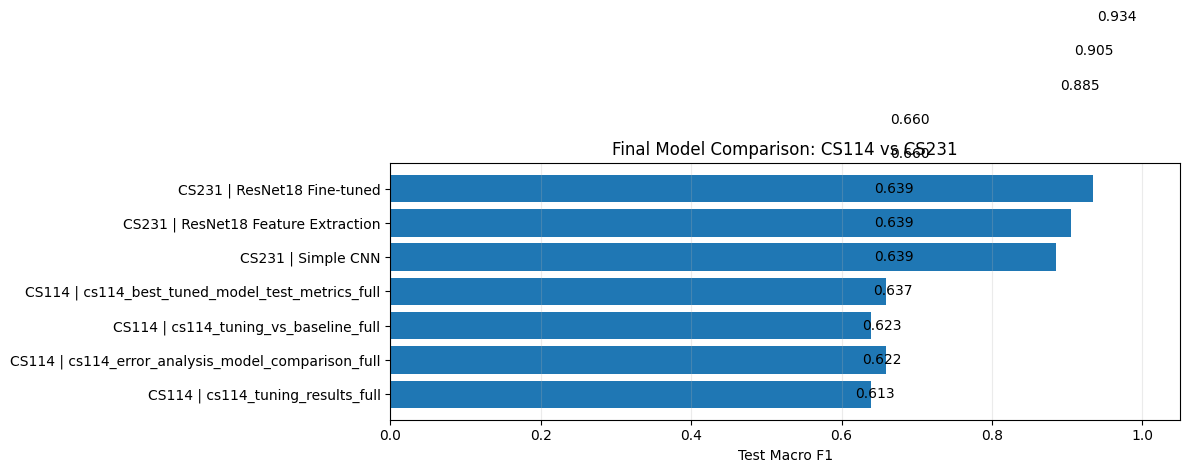

In [ ]:
cs231_for_final = cs231_summary_df.copy()
cs231_for_final["group"] = "CS231"
cs231_for_final["feature_or_input"] = cs231_for_final["model"].map({
    "Simple CNN": "Raw image 128x128",
    "ResNet18 Feature Extraction": "Raw image 224x224 + ImageNet pretrained features",
    "ResNet18 Fine-tuned": "Raw image 224x224 + fine-tuned layer4/fc",
}).fillna("Raw image")

cs231_for_final = cs231_for_final[[
    "group",
    "model",
    "feature_or_input",
    "test_accuracy",
    "test_macro_f1",
]].copy()
cs231_for_final["source_file"] = "cs231_cnn_model_comparison.csv"

if len(cs114_df) > 0:
    final_comparison_df = pd.concat([cs114_df, cs231_for_final], ignore_index=True, sort=False)
else:
    final_comparison_df = cs231_for_final.copy()

final_comparison_df = final_comparison_df.sort_values("test_macro_f1", ascending=False, na_position="last").reset_index(drop=True)

display(final_comparison_df)
save_dataframe(final_comparison_df, METRIC_DIR / "final_cs114_cs231_model_comparison.csv")

if len(final_comparison_df) > 0:
    plot_df = final_comparison_df.dropna(subset=["test_macro_f1"]).copy()
    plot_df = plot_df.head(12).iloc[::-1]

    plt.figure(figsize=(12, max(6, 0.45 * len(plot_df))))
    labels = plot_df["group"] + " | " + plot_df["model"].astype(str)
    plt.barh(labels, plot_df["test_macro_f1"].astype(float))
    plt.xlabel("Test Macro F1")
    plt.title("Final Model Comparison: CS114 vs CS231")
    plt.xlim(0, 1.05)
    plt.grid(axis="x", alpha=0.25)

    for i, value in enumerate(plot_df["test_macro_f1"].astype(float)):
        plt.text(value + 0.005, i, f"{value:.3f}", va="center")

    save_current_figure(FINAL_FIGURE_DIR / "cs114_cs231_model_comparison_macro_f1.png")
    plt.show()


## 25. Sinh nhận xét tự động dùng cho báo cáo

Cell này tạo file markdown tóm tắt kết quả dựa trên metrics thực tế.

Bạn có thể copy nội dung từ file này vào báo cáo rồi chỉnh câu chữ theo yêu cầu môn học.


In [ ]:
def format_pct(x: Any) -> str:
    try:
        return f"{float(x) * 100:.2f}%"
    except Exception:
        return "N/A"


report_lines = []
report_lines.append("# CS231 CNN Evaluation Summary")
report_lines.append("")
report_lines.append("## 1. Dataset split")
report_lines.append(f"- Train: {len(train_df)} images")
report_lines.append(f"- Validation: {len(val_df)} images")
report_lines.append(f"- Test: {len(test_df)} images")
report_lines.append(f"- Classes: {', '.join(class_names)}")
report_lines.append("")

report_lines.append("## 2. Overall test metrics")

for _, row in cs231_summary_df.iterrows():
    report_lines.append(
        f"- {row['model']}: Accuracy = {format_pct(row['test_accuracy'])}, "
        f"Macro F1 = {format_pct(row['test_macro_f1'])}, "
        f"Wrong = {int(row['num_wrong'])}/{int(row['num_test_samples'])}."
    )

report_lines.append("")

if len(cs231_summary_df) > 0:
    best = cs231_summary_df.iloc[0]
    report_lines.append("## 3. Main conclusion")
    report_lines.append(
        f"- The best CS231 model is **{best['model']}**, achieving "
        f"Accuracy = {format_pct(best['test_accuracy'])} and Macro F1 = {format_pct(best['test_macro_f1'])}."
    )

if "simple_cnn" in metrics and "resnet18_finetuned" in metrics:
    acc_delta = metrics["resnet18_finetuned"]["accuracy"] - metrics["simple_cnn"]["accuracy"]
    f1_delta = metrics["resnet18_finetuned"]["macro_f1"] - metrics["simple_cnn"]["macro_f1"]
    wrong_reduction = metrics["simple_cnn"]["num_wrong"] - metrics["resnet18_finetuned"]["num_wrong"]

    report_lines.append(
        f"- Compared with Simple CNN, ResNet18 Fine-tuned improves Accuracy by {acc_delta * 100:.2f} percentage points, "
        f"Macro F1 by {f1_delta * 100:.2f} percentage points, and reduces {wrong_reduction} wrong predictions on the test set."
    )

report_lines.append("")
report_lines.append("## 4. Error analysis notes")

main_key = "resnet18_finetuned" if "resnet18_finetuned" in top_confusion_tables else None

if main_key is not None:
    top_df = top_confusion_tables[main_key].head(8)
    report_lines.append("Top confused pairs of ResNet18 Fine-tuned:")

    for _, row in top_df.iterrows():
        report_lines.append(
            f"- {row['true_label']} → {row['pred_label']}: {int(row['count'])} images "
            f"({row['rate_within_true_class'] * 100:.2f}% within true class)."
        )

report_lines.append("")
report_lines.append("Recommended interpretation:")
report_lines.append("- Forest is usually easier because vegetation texture and color patterns are visually distinctive.")
report_lines.append("- Glacier and mountain are often confused because many images share snow, rock, sky, and terrain structures.")
report_lines.append("- Buildings and street can be confused because street scenes often contain many buildings and urban structures.")
report_lines.append("- Sea can overlap visually with glacier or mountain when the scene contains horizon, bright regions, or distant terrain.")

report_text = "\n".join(report_lines)
summary_path = METRIC_DIR / "cs231_report_ready_summary.md"
summary_path.write_text(report_text, encoding="utf-8")

print("Saved:", summary_path)
display(Markdown(report_text))


Saved: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/metrics/cs231_report_ready_summary.md


# CS231 CNN Evaluation Summary

## 1. Dataset split
- Train: 11212 images
- Validation: 2804 images
- Test: 3000 images
- Classes: buildings, forest, glacier, mountain, sea, street

## 2. Overall test metrics
- ResNet18 Fine-tuned: Accuracy = 93.33%, Macro F1 = 93.44%, Wrong = 200/3000.
- ResNet18 Feature Extraction: Accuracy = 90.33%, Macro F1 = 90.45%, Wrong = 290/3000.
- Simple CNN: Accuracy = 88.47%, Macro F1 = 88.50%, Wrong = 346/3000.

## 3. Main conclusion
- The best CS231 model is **ResNet18 Fine-tuned**, achieving Accuracy = 93.33% and Macro F1 = 93.44%.
- Compared with Simple CNN, ResNet18 Fine-tuned improves Accuracy by 4.87 percentage points, Macro F1 by 4.94 percentage points, and reduces 146 wrong predictions on the test set.

## 4. Error analysis notes
Top confused pairs of ResNet18 Fine-tuned:
- glacier → mountain: 55 images (9.95% within true class).
- mountain → glacier: 36 images (6.86% within true class).
- street → buildings: 36 images (7.19% within true class).
- buildings → street: 22 images (5.03% within true class).
- glacier → sea: 18 images (3.25% within true class).
- mountain → sea: 8 images (1.52% within true class).
- sea → mountain: 6 images (1.18% within true class).
- glacier → forest: 4 images (0.72% within true class).

Recommended interpretation:
- Forest is usually easier because vegetation texture and color patterns are visually distinctive.
- Glacier and mountain are often confused because many images share snow, rock, sky, and terrain structures.
- Buildings and street can be confused because street scenes often contain many buildings and urban structures.
- Sea can overlap visually with glacier or mountain when the scene contains horizon, bright regions, or distant terrain.

## 26. Copy kết quả về Google Drive nếu chạy trên Colab local

Nếu bạn đang dùng `/content/intel_image_project`, cell này sẽ copy `outputs/` và `models/` về project trên Google Drive.


In [ ]:
if IN_COLAB and DRIVE_ROOT is not None and PROJECT_ROOT != DRIVE_ROOT:
    print("Đang copy outputs và models về Google Drive...")

    drive_output_dir = DRIVE_ROOT / "outputs"
    drive_model_dir = DRIVE_ROOT / "models"

    def sync_dir(src: Path, dst: Path) -> None:
        src = Path(src)
        dst = Path(dst)
        dst.mkdir(parents=True, exist_ok=True)

        try:
            subprocess.run(
                ["rsync", "-ah", "--info=progress2", str(src) + "/", str(dst) + "/"],
                check=True
            )
        except Exception as e:
            print("rsync không chạy được, dùng shutil.copytree fallback.")
            print("Lý do:", repr(e))
            shutil.copytree(src, dst, dirs_exist_ok=True)

    sync_dir(PROJECT_ROOT / "outputs", drive_output_dir)
    sync_dir(PROJECT_ROOT / "models", drive_model_dir)

    print("Đã copy xong.")
else:
    print("Không cần copy hoặc đang chạy trực tiếp trên Drive/local.")


Không cần copy hoặc đang chạy trực tiếp trên Drive/local.


# Checklist sau khi chạy file 09

Sau khi chạy xong notebook, bạn nên kiểm tra các file quan trọng sau:

```text
outputs/metrics/cs231_cnn_model_comparison.csv
outputs/metrics/cs231_prediction_integrity_check.csv
outputs/metrics/cs231_all_models_per_class_metrics.csv
outputs/metrics/final_cs114_cs231_model_comparison.csv
outputs/metrics/cs231_report_ready_summary.md

outputs/figures/cs231/cs231_model_comparison_accuracy_macro_f1.png
outputs/figures/cs231/validation_macro_f1_all_models.png
outputs/figures/cs231/resnet18_finetuned_confusion_matrix_normalized.png
outputs/figures/cs231/resnet18_finetuned_top_confused_pairs.png
outputs/figures/cs231/gradcam/simple_cnn_gradcam_correct_examples.png
outputs/figures/cs231/gradcam/simple_cnn_gradcam_misclassified_examples.png
outputs/figures/cs231/gradcam/resnet18_finetuned_gradcam_correct_examples.png
outputs/figures/cs231/gradcam/resnet18_finetuned_gradcam_misclassified_examples.png
outputs/metrics/simple_cnn_gradcam_correct_examples.csv
outputs/metrics/simple_cnn_gradcam_misclassified_examples.csv
outputs/metrics/resnet18_finetuned_gradcam_correct_examples.csv
outputs/metrics/resnet18_finetuned_gradcam_misclassified_examples.csv
outputs/figures/cs231/per_class_f1_score_comparison.png
outputs/figures/cs231/misclassified_examples/resnet18_finetuned_misclassified_examples.png
outputs/figures/final/cs114_cs231_model_comparison_macro_f1.png
```


